# Let's Look inside of what we've gathered

In [83]:
import json

In [84]:
def read_jsonl(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                # This turns the string '{"id": 1}' into a real dict {'id': 1}
                data.append(json.loads(line)) 
        return data

In [85]:
metadata = read_jsonl("metadata.jsonl")

In [86]:
metadata[0]

{'original_video': 'SPAPelotas - gatinhos mamando..mp4',
 'processed_at': '2026-02-20T20:01:06.940246',
 'total_chunks_analyzed': 6,
 'saved_chunks_count': 3,
 'snippets': [{'id': 'SPAPelotas - gatinhos mamando._snip_1',
   'audio_proba': 0.6237,
   'timestamp_range': [24.33, 31.33],
   'duration': 7.0},
  {'id': 'SPAPelotas - gatinhos mamando._snip_3',
   'audio_proba': 0.5806,
   'timestamp_range': [62.2, 69.2],
   'duration': 7.0},
  {'id': 'SPAPelotas - gatinhos mamando._snip_4',
   'audio_proba': 0.6464,
   'timestamp_range': [77.8, 84.8],
   'duration': 7.0}]}

## Small Statistics

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
# Assuming 'data_list' is the list of dictionaries from your read_jsonl method
df_videos = pd.DataFrame(metadata)

In [89]:
# 1.1 Video Files Amount
total_videos = len(df_videos)
print(f"📁 Total Videos Processed: {total_videos}")

# 1.2 Ratio Calculation
df_videos['hit_ratio'] = df_videos['saved_chunks_count'] / df_videos['total_chunks_analyzed']

# 1.3 Plotting Video-Level Stats
plt.figure(figsize=(12, 5))

# Plot Hit Ratio
plt.subplot(1, 2, 1)
mean_ratio = df_videos['hit_ratio'].mean()
median_ratio = df_videos['hit_ratio'].median()

sns.histplot(df_videos['hit_ratio'], bins=15, kde=True, color='teal')
plt.axvline(mean_ratio, color='red', linestyle='--', label=f'Mean: {mean_ratio:.2f}')
plt.axvline(median_ratio, color='orange', linestyle='-', label=f'Median: {median_ratio:.2f}')
plt.title("Ratio of Saved Chunks to Analyzed")
plt.legend()

📁 Total Videos Processed: 728


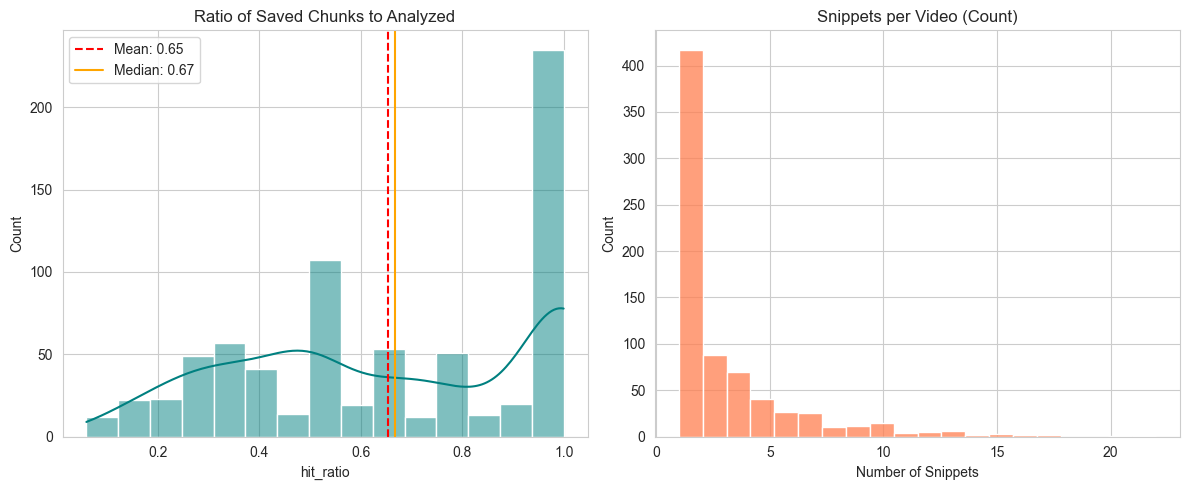

In [90]:
# Plot Snippets per Video
plt.subplot(1, 2, 2)
sns.histplot(df_videos['saved_chunks_count'], bins=20, kde=False, color='coral')
plt.title("Snippets per Video (Count)")
plt.xlabel("Number of Snippets")

plt.tight_layout()
plt.show()

In [91]:
# 2. Reformat into a flat list
flattened_data = []

for video in metadata:
    for snip in video['snippets']:
        # Create a new dict combining video name + snippet data
        flat_entry = {
            "original_video": video['original_video'],
            **snip # This unpacks all fields from the snippet dict
        }
        flattened_data.append(flat_entry)

df_snippets = pd.DataFrame(flattened_data)

# Show the first few rows of the new clean table
print(f"✨ Created flat table with {len(df_snippets)} total snippets.")
display(df_snippets.head())

✨ Created flat table with 2358 total snippets.


,original_video,id,audio_proba,timestamp_range,duration
0,SPAPelotas - gatinhos mamando..mp4,SPAPelotas - gatinhos mamando._snip_1,0.6237,"[24.33, 31.33]",7.00
1,SPAPelotas - gatinhos mamando..mp4,SPAPelotas - gatinhos mamando._snip_3,0.5806,"[62.2, 69.2]",7.00
2,SPAPelotas - gatinhos mamando..mp4,SPAPelotas - gatinhos mamando._snip_4,0.6464,"[77.8, 84.8]",7.00
3,MPC Cat.mp4,MPC Cat_snip_0,0.7449,"[6.71, 11.44]",4.73
4,MPC Cat.mp4,MPC Cat_snip_1,0.8439,"[26.33, 29.66]",3.33


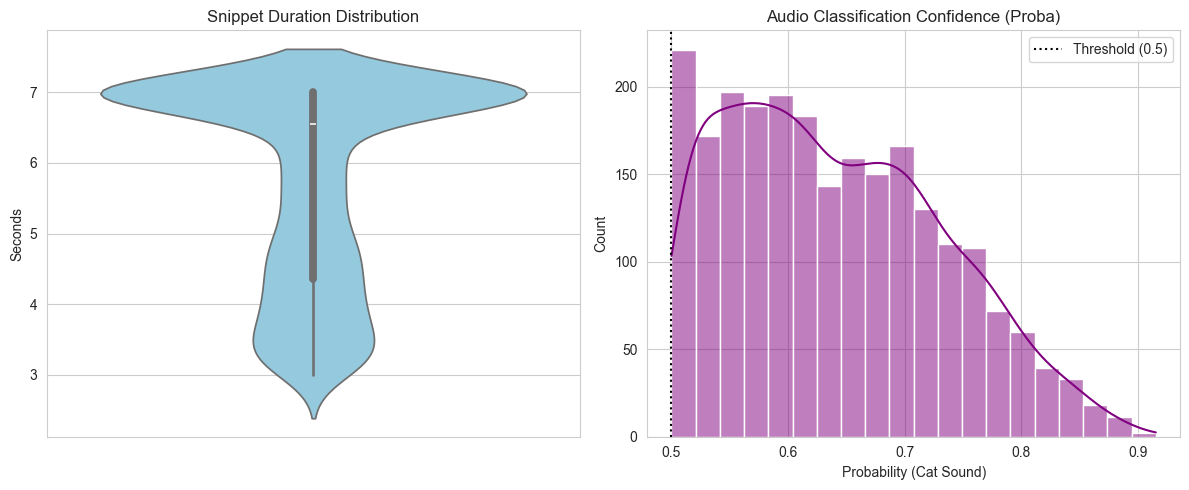

In [92]:
plt.figure(figsize=(12, 5))

# 3.1 Duration Distribution
plt.subplot(1, 2, 1)
sns.violinplot(y=df_snippets['duration'], color='skyblue')
# A violin plot is better than a histogram here because it shows density 
# and the exact distribution between your 3s and 7s limits.
plt.title("Snippet Duration Distribution")
plt.ylabel("Seconds")

# 3.2 Audio Probability
plt.subplot(1, 2, 2)
sns.histplot(df_snippets['audio_proba'], bins=20, kde=True, color='purple')
plt.axvline(0.5, color='black', linestyle=':', label='Threshold (0.5)')
plt.title("Audio Classification Confidence (Proba)")
plt.xlabel("Probability (Cat Sound)")
plt.legend()

plt.tight_layout()
plt.show()

## Labeling with Audio classifier

In [93]:
from audio_classifier_utils.audio_config import AudioConfig
from audio_classifier_utils.models.cnn14 import CatEmotionModel
from audio_classifier_utils.dataset import CatEmotionDataset
from torch.utils.data import DataLoader

import torch
import numpy as np
from tqdm.auto import tqdm

In [94]:
audio_config = AudioConfig()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [95]:
# Instantiate the model architecture
model = CatEmotionModel(audio_config)

Loading pre-trained weights from audio_classifier_utils/pretrained_weights/Cnn14_16k_mAP=0.438.pth...
Weights loaded successfully!


In [96]:
# Load the weights from your .pth file
checkpoint = torch.load("checkpoints/best_model_final.pth", map_location=device)

In [97]:
# If you saved a state_dict (recommended):
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [98]:
model.to(device)
model.eval() # 🛑 CRITICAL: Turns off Dropout and locks BatchNorm layers

CatEmotionModel(
  (backbone): Cnn14(
    (spectrogram_extractor): Spectrogram(
      (stft): STFT(
        (conv_real): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
        (conv_imag): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
      )
    )
    (logmel_extractor): LogmelFilterBank()
    (spec_augmenter): SpecAugmentation(
      (time_dropper): DropStripes()
      (freq_dropper): DropStripes()
    )
    (bn0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv_block1): ConvBlock(
      (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (conv_block2): ConvBlock(
      (conv1): Conv2d(64, 128

In [99]:
flattened_data[:2]

[{'original_video': 'SPAPelotas - gatinhos mamando..mp4',
  'id': 'SPAPelotas - gatinhos mamando._snip_1',
  'audio_proba': 0.6237,
  'timestamp_range': [24.33, 31.33],
  'duration': 7.0},
 {'original_video': 'SPAPelotas - gatinhos mamando..mp4',
  'id': 'SPAPelotas - gatinhos mamando._snip_3',
  'audio_proba': 0.5806,
  'timestamp_range': [62.2, 69.2],
  'duration': 7.0}]

In [100]:
inference_data = [
    f"dataset_snippets/{row['id']}.mp3" for row in flattened_data
]

In [101]:
inference_data[:3]

['dataset_snippets/SPAPelotas - gatinhos mamando._snip_1.mp3',
 'dataset_snippets/SPAPelotas - gatinhos mamando._snip_3.mp3',
 'dataset_snippets/SPAPelotas - gatinhos mamando._snip_4.mp3']

In [102]:
# 2. 🌟 THE FIX: Convert them to tuples with a dummy label (-1)
inference_files = [(path, -1) for path in inference_data]
# Now it looks like: [("dataset_snippets/video1_snip_0.mp3", -1), ...]

In [103]:
# Use train=False to disable data augmentations (like random noise or pitch shifting)
inference_dataset = CatEmotionDataset(inference_files, audio_config, train=False)

In [104]:
# You can use a larger batch size for inference since we aren't storing gradients
inference_loader = DataLoader(inference_dataset, batch_size=64, shuffle=False)

In [105]:
# 3. The Inference Loop
all_predictions = []
all_probabilities = []

# 🛑 CRITICAL: Disable gradient calculation
with torch.no_grad():
    # Wrap the loader in tqdm
    # We use unit="batch" because each step processes a batch_size of snippets
    pbar = tqdm(inference_loader, desc="🧠 Running Emotion Inference", unit="batch")
    
    for batch in pbar:
        # Handling the tuple/list/dict structure
        if isinstance(batch, (tuple, list)):
            inputs = batch[0].to(device)
        elif isinstance(batch, dict):
            inputs = batch['audio'].to(device)
        else:
            inputs = batch.to(device)

        # Forward pass
        logits = model(inputs)
        
        # Probabilities and Predictions
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        # Store results
        all_probabilities.extend(probs.cpu().numpy())
        all_predictions.extend(preds.cpu().tolist())
        
        # Optional: Update the progress bar with a count of total snippets gathered so far
        pbar.set_postfix({"total_snips": len(all_predictions)})

print(f"✅ Inference complete. Processed {len(all_predictions)} snippets.")

🧠 Running Emotion Inference: 100%|██████████| 37/37 [00:33<00:00,  1.10batch/s, total_snips=2358]

✅ Inference complete. Processed 2358 snippets.


In [106]:
all_predictions[:3], all_probabilities[:3]

([6, 6, 7],
 [array([1.2436222e-05, 2.3187159e-08, 7.6404208e-04, 4.7365051e-02,
         5.0327573e-03, 3.1274633e-04, 8.6231774e-01, 8.4194034e-02,
         5.3179321e-07, 5.2794115e-07], dtype=float32),
  array([3.3414082e-07, 1.1657348e-09, 4.9501639e-05, 4.0225382e-03,
         3.3901881e-05, 2.2585382e-06, 9.4571060e-01, 5.0180793e-02,
         1.0655401e-08, 1.8546894e-08], dtype=float32),
  array([5.1937187e-03, 1.7666954e-06, 3.1677010e-03, 1.2492096e-01,
         7.5405827e-03, 5.6480663e-03, 2.9674482e-01, 5.5672354e-01,
         7.1638083e-06, 5.1698004e-05], dtype=float32)])

In [107]:
idx_to_class = {
    0: 'Angry',
    1: 'Defence',
    2: 'Fighting',
    3: 'Happy',
    4: 'HuntingMind',
    5: 'Mating',
    6: 'MotherCall',
    7: 'Paining',
    8: 'Resting',
    9: 'Warning'
}

/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_78671/121977666.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_preds, x='emotion', order=order, palette='magma')


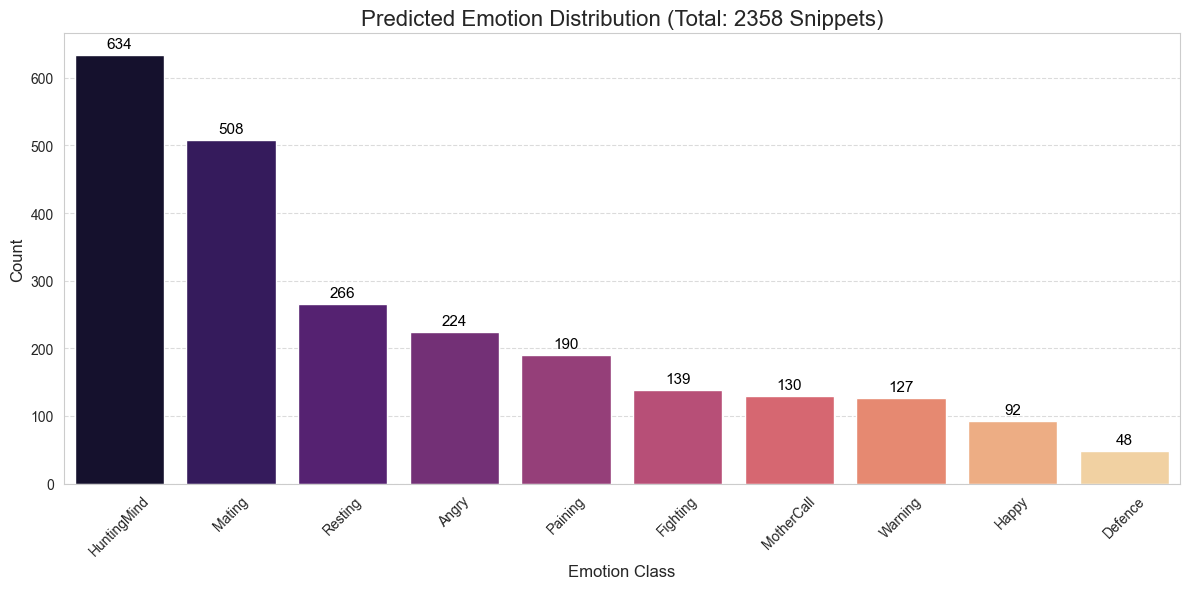

In [108]:
# 1. Map the numeric predictions to their string labels
predicted_labels = [idx_to_class[pred] for pred in all_predictions]

# 2. Create a DataFrame for easy plotting
df_preds = pd.DataFrame({
    'emotion': predicted_labels,
    'confidence': [float(np.max(prob)) for prob in all_probabilities]
})

# 3. Plot the Distribution
plt.figure(figsize=(12, 6))

# We sort by count to make the "dominant" emotions stand out
order = df_preds['emotion'].value_counts().index
ax = sns.countplot(data=df_preds, x='emotion', order=order, palette='magma')

# Add total counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title(f'Predicted Emotion Distribution (Total: {len(df_preds)} Snippets)', fontsize=16)
plt.xlabel('Emotion Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [109]:
# 4. Print Summary Stats
print("📊 Emotion Summary:")
print(df_preds['emotion'].value_counts())
print(f"\n💡 Average Model Confidence: {df_preds['confidence'].mean():.2%}")

📊 Emotion Summary:
emotion
HuntingMind    634
Mating         508
Resting        266
Angry          224
Paining        190
Fighting       139
MotherCall     130
Warning        127
Happy           92
Defence         48
Name: count, dtype: int64

💡 Average Model Confidence: 70.85%


/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_78671/935029384.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_probs, x='Emotion', y='Confidence', order=class_order, palette='viridis')


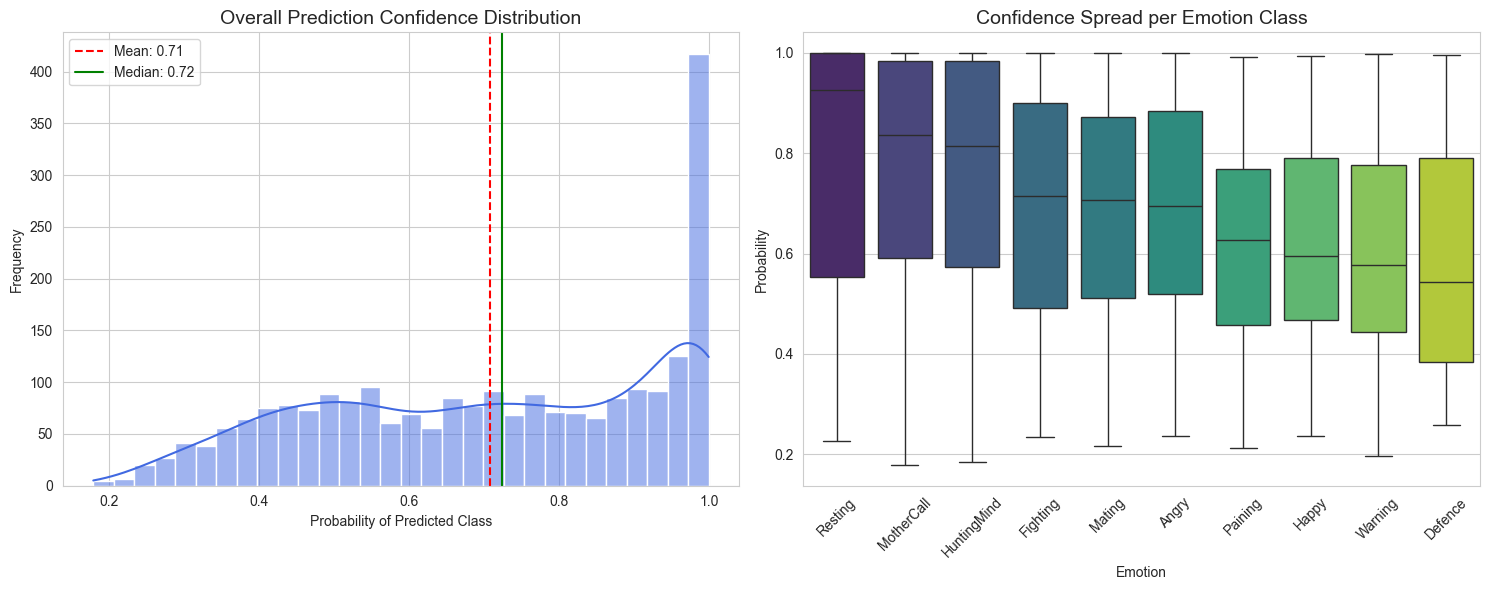

In [110]:
# 1. Prepare the data
# Extract the maximum probability (confidence) for each prediction
confidences = [float(np.max(prob)) for prob in all_probabilities]
labels = [idx_to_class[pred] for pred in all_predictions]

df_probs = pd.DataFrame({
    'Emotion': labels,
    'Confidence': confidences
})

# 2. Create the Visualizations
plt.figure(figsize=(15, 6))

# Plot A: Overall Confidence Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_probs['Confidence'], bins=30, kde=True, color='royalblue')
plt.axvline(df_probs['Confidence'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df_probs['Confidence'].mean():.2f}")
plt.axvline(df_probs['Confidence'].median(), color='green', linestyle='-', 
            label=f"Median: {df_probs['Confidence'].median():.2f}")
plt.title('Overall Prediction Confidence Distribution', fontsize=14)
plt.xlabel('Probability of Predicted Class')
plt.ylabel('Frequency')
plt.legend()

# Plot B: Confidence spread per Class (Boxplot)
plt.subplot(1, 2, 2)
# Sorting classes by their median confidence for better readability
class_order = df_probs.groupby('Emotion')['Confidence'].median().sort_values(ascending=False).index
sns.boxplot(data=df_probs, x='Emotion', y='Confidence', order=class_order, palette='viridis')
plt.xticks(rotation=45)
plt.title('Confidence Spread per Emotion Class', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Probability')

plt.tight_layout()
plt.show()

In [111]:
# 3. Print detailed stats
stats = df_probs.groupby('Emotion')['Confidence'].agg(['count', 'mean', 'std']).sort_values(by='mean', ascending=False)
print("📊 Detailed Confidence Stats per Class:")
print(stats)

📊 Detailed Confidence Stats per Class:
             count      mean       std
Emotion                               
Resting        266  0.786879  0.250135
HuntingMind    634  0.763659  0.223229
MotherCall     130  0.760451  0.235125
Fighting       139  0.693298  0.222921
Angry          224  0.690240  0.214266
Mating         508  0.683601  0.208174
Happy           92  0.626523  0.199400
Paining        190  0.617644  0.190349
Warning        127  0.605623  0.214689
Defence         48  0.587124  0.237912


In [112]:
# 1. Function to extract the deep features (embeddings)
def get_embeddings(model, loader, device='cuda'):
    print("Extracting 2048-D embeddings from the CNN14 backbone...")
    model.eval()
    model.to(device)
    
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for waveforms, labels in loader:
            waveforms = waveforms.to(device)
            
            # Instead of calling model(waveforms) which gives the final 10 classes,
            # we call the backbone directly to get the deep features!
            output_dict = model.backbone(waveforms)
            embeddings = output_dict['embedding'] # Shape: (Batch, 2048)
            
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.append(labels.numpy())
            
    # Stack all batches into one giant numpy array
    return np.vstack(all_embeddings), np.concatenate(all_labels)

In [113]:
# Note: Use the inference_loader we set up (the one with the dummy labels)
embeddings_2048, _ = get_embeddings(model, inference_loader, device=device)

Extracting 2048-D embeddings from the CNN14 backbone...


In [114]:
# 2. Prepare the labels and confidence for the plot
# We use 'all_predictions' and 'all_probabilities' from your previous inference run
predicted_emotions = [p for p in all_predictions]
confidences = [float(np.max(prob)) for prob in all_probabilities]

In [115]:
print(f"✅ Features ({embeddings_2048.shape}) and Labels ({len(predicted_emotions)}) ready.")

✅ Features ((2358, 2048)) and Labels (2358) ready.


In [116]:
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
def plot_tsne_galaxy_map(embeddings, labels, class_names=None):
    print(f"Running t-SNE on {embeddings.shape[0]} audio files. This might take a minute...")
    
    # 1. Reset to Matplotlib defaults and set Seaborn light style
    plt.rcParams.update(plt.rcParamsDefault)
    sns.set_style("whitegrid")

    # Initialize t-SNE. 
    # Perplexity is a tuneable parameter usually between 5 and 50. 30 is standard.
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    
    # Squash 2048 dimensions down to 2 dimensions!
    tsne_results = tsne.fit_transform(embeddings)
    
    # Map numeric labels to names if provided
    if class_names:
        plot_labels = [class_names[label] for label in labels]
    else:
        plot_labels = [f"Class {label}" for label in labels]
    
    # Create a beautiful seaborn plot
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x=tsne_results[:, 0], 
        y=tsne_results[:, 1],
        hue=plot_labels,
        palette="tab10", # A great color palette for 10 classes
        legend="full",
        alpha=0.9,
        s=60, # Size of the dots
        edgecolor='k',
        linewidth=0.5
    )
    
    plt.title("t-SNE 'Galaxy Map' of Cat Emotion Audio Features", fontsize=16, pad=20)
    plt.xlabel("t-SNE Dimension 1", fontsize=12)
    plt.ylabel("t-SNE Dimension 2", fontsize=12)
    
    # Clean up the legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Emotions")
    plt.tight_layout()
    plt.show()

Running t-SNE on 2358 audio files. This might take a minute...


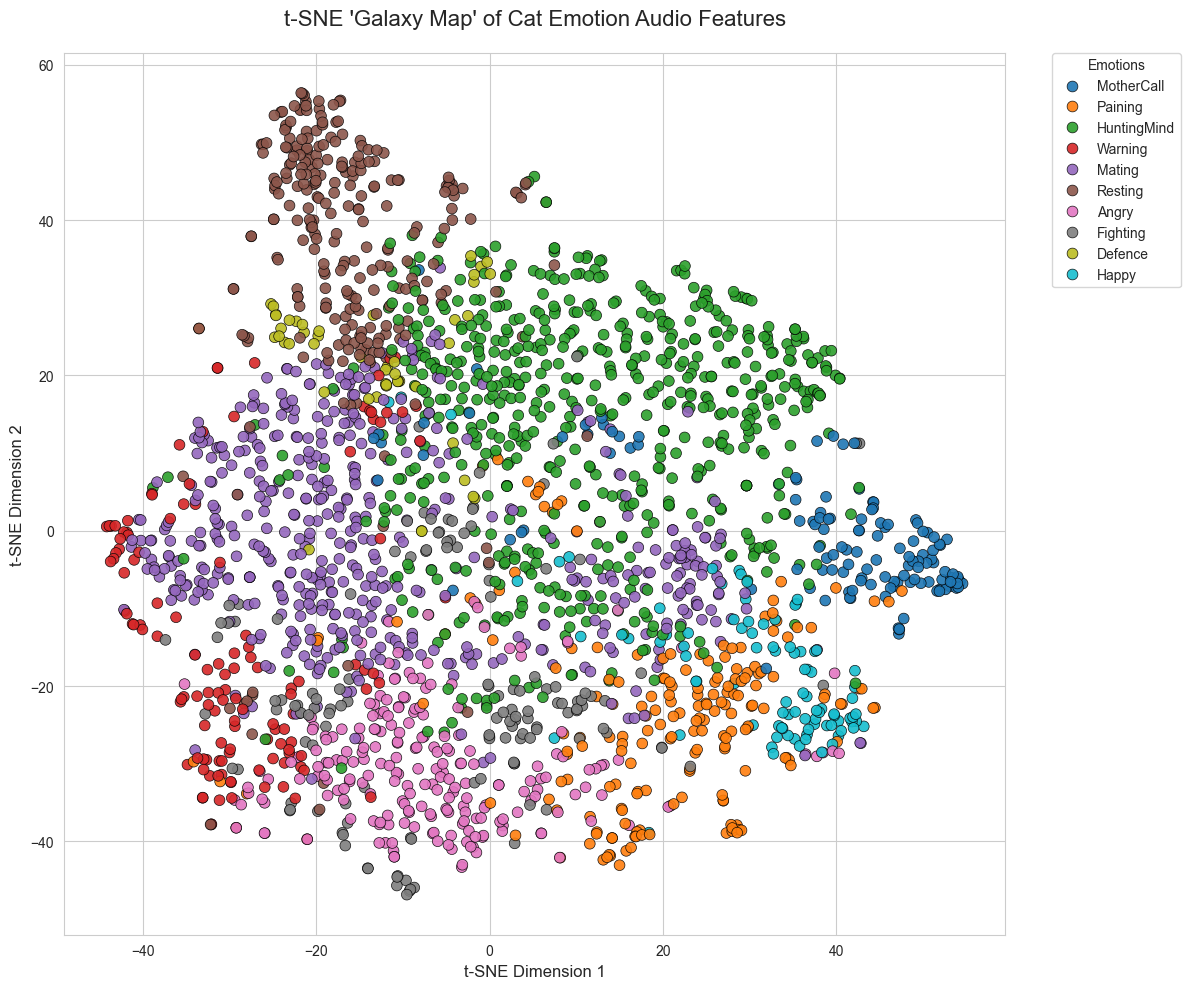

In [118]:
plot_tsne_galaxy_map(embeddings_2048, predicted_emotions, idx_to_class)

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler


def plot_tsne_galaxy_map(embeddings, labels, class_names=None):
    print(f"\nRunning cluster analysis on {embeddings.shape[0]} samples...")

    # --------------------------------------------------
    # 1️⃣ Normalize embeddings (important for distance metrics)
    # --------------------------------------------------
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings)

    # --------------------------------------------------
    # 2️⃣ Compute cluster quality metrics (ORIGINAL SPACE)
    # --------------------------------------------------
    sil_score = silhouette_score(embeddings_scaled, labels)
    db_score = davies_bouldin_score(embeddings_scaled, labels)
    ch_score = calinski_harabasz_score(embeddings_scaled, labels)

    print("\nCluster Quality Metrics (computed in 2048-D space)")
    print("--------------------------------------------------")
    print(f"Silhouette Score:           {sil_score:.4f}  (↑ better, max=1)")
    print(f"Davies-Bouldin Index:       {db_score:.4f}  (↓ better)")
    print(f"Calinski-Harabasz Score:    {ch_score:.2f}  (↑ better)")

    # Class-wise silhouette
    sil_samples = silhouette_samples(embeddings_scaled, labels)
    print("\nPer-Class Mean Silhouette:")
    for cls in np.unique(labels):
        cls_mask = labels == cls
        mean_sil = sil_samples[cls_mask].mean()
        name = class_names[cls] if class_names else f"Class {cls}"
        print(f"{name:<15} : {mean_sil:.4f}")

    # --------------------------------------------------
    # 3️⃣ t-SNE Projection (for visualization only)
    # --------------------------------------------------
    print("\nRunning t-SNE projection...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_results = tsne.fit_transform(embeddings_scaled)

    if class_names:
        plot_labels = [class_names[label] for label in labels]
    else:
        plot_labels = [f"Class {label}" for label in labels]

    # --------------------------------------------------
    # 4️⃣ Plot
    # --------------------------------------------------
    plt.rcParams.update(plt.rcParamsDefault)
    sns.set_style("whitegrid")

    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x=tsne_results[:, 0],
        y=tsne_results[:, 1],
        hue=plot_labels,
        palette="tab10",
        legend="full",
        alpha=0.9,
        s=60,
        edgecolor='k',
        linewidth=0.5
    )

    plt.title("t-SNE 'Galaxy Map' of Cat Emotion Audio Features", fontsize=16, pad=20)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0., title="Emotions")

    plt.tight_layout()
    plt.show()


Running cluster analysis on 2358 samples...

Cluster Quality Metrics (computed in 2048-D space)
--------------------------------------------------
Silhouette Score:           -0.0188  (↑ better, max=1)
Davies-Bouldin Index:       3.6294  (↓ better)
Calinski-Harabasz Score:    35.20  (↑ better)

Per-Class Mean Silhouette:
Angry           : -0.0247
Defence         : -0.1994
Fighting        : -0.1424
Happy           : -0.0221
HuntingMind     : -0.0823
Mating          : 0.1675
MotherCall      : -0.0779
Paining         : 0.0180
Resting         : -0.0617

Running t-SNE projection...


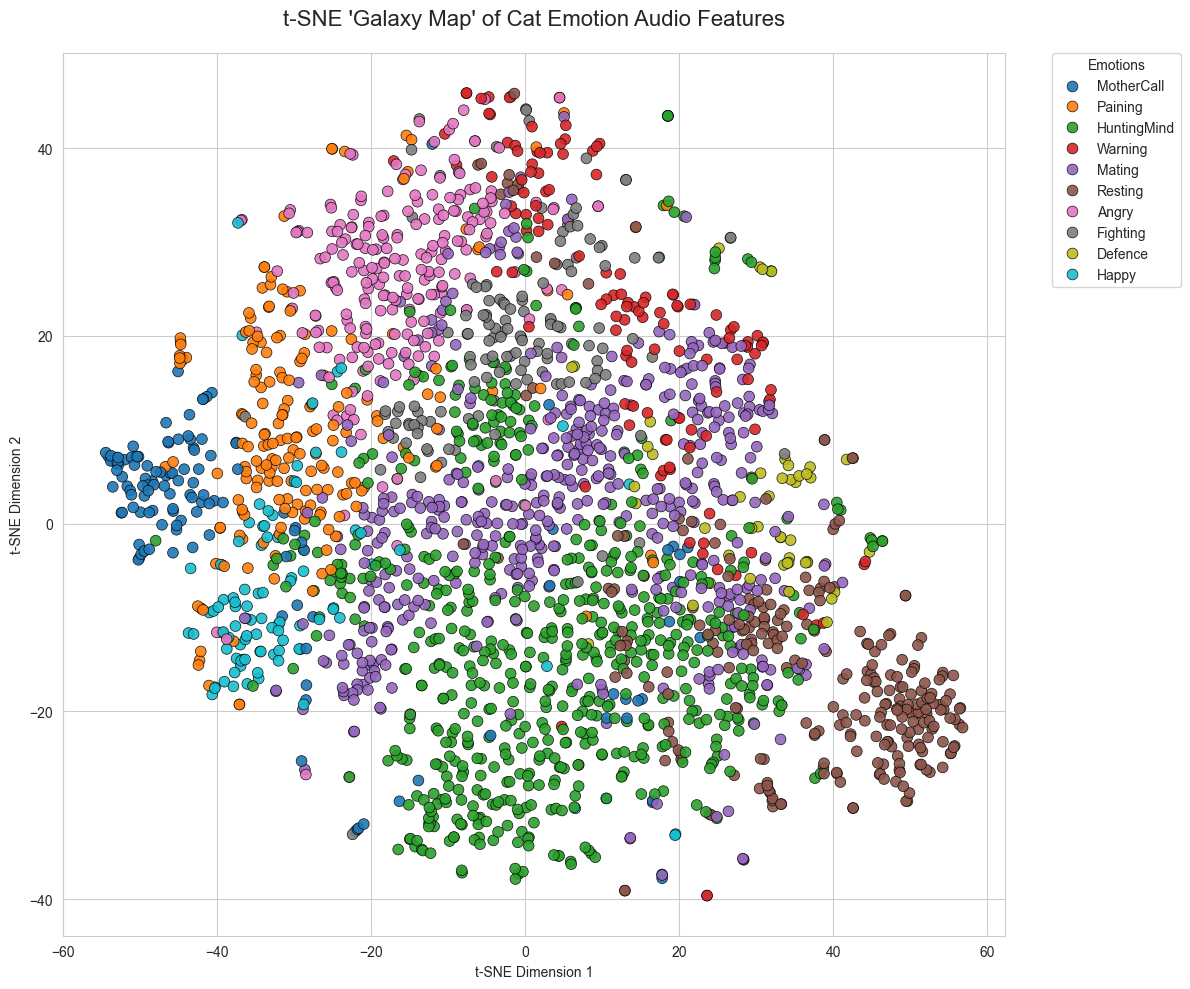

In [120]:
plot_tsne_galaxy_map(embeddings_2048, predicted_emotions, idx_to_class)

## B U T: what if 65%?

In [121]:
flattened_data_chosen = [
    row for row in flattened_data if row['audio_proba'] > 0.6
]
len(flattened_data_chosen), len(flattened_data)

(1425, 2358)

In [122]:
audio_config = AudioConfig()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Instantiate the model architecture
model = CatEmotionModel(audio_config)

# Load the weights from your .pth file
checkpoint = torch.load("checkpoints/best_model_final.pth", map_location=device)

# If you saved a state_dict (recommended):
model.load_state_dict(checkpoint['model_state_dict'])

model.to(device)
model.eval() # 🛑 CRITICAL: Turns off Dropout and locks BatchNorm layers

Loading pre-trained weights from audio_classifier_utils/pretrained_weights/Cnn14_16k_mAP=0.438.pth...
Weights loaded successfully!


CatEmotionModel(
  (backbone): Cnn14(
    (spectrogram_extractor): Spectrogram(
      (stft): STFT(
        (conv_real): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
        (conv_imag): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
      )
    )
    (logmel_extractor): LogmelFilterBank()
    (spec_augmenter): SpecAugmentation(
      (time_dropper): DropStripes()
      (freq_dropper): DropStripes()
    )
    (bn0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv_block1): ConvBlock(
      (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (conv_block2): ConvBlock(
      (conv1): Conv2d(64, 128

In [123]:
inference_data_chosen = [
    f"dataset_snippets/{row['id']}.mp3" for row in flattened_data_chosen
]

In [124]:
inference_data_chosen[:3]

['dataset_snippets/SPAPelotas - gatinhos mamando._snip_1.mp3',
 'dataset_snippets/SPAPelotas - gatinhos mamando._snip_4.mp3',
 'dataset_snippets/MPC Cat_snip_0.mp3']

In [125]:
# 2. 🌟 THE FIX: Convert them to tuples with a dummy label (-1)
inference_files_chosen = [(path, -1) for path in inference_data_chosen]
# Now it looks like: [("dataset_snippets/video1_snip_0.mp3", -1), ...]

In [126]:
# Use train=False to disable data augmentations (like random noise or pitch shifting)
inference_dataset_chosen = CatEmotionDataset(inference_files_chosen, audio_config, train=False)

In [127]:
# You can use a larger batch size for inference since we aren't storing gradients
inference_loader_chosen = DataLoader(inference_dataset_chosen, batch_size=64, shuffle=False)

In [128]:
# 3. The Inference Loop
all_predictions = []
all_probabilities = []

# 🛑 CRITICAL: Disable gradient calculation
with torch.no_grad():
    # Wrap the loader in tqdm
    # We use unit="batch" because each step processes a batch_size of snippets
    pbar = tqdm(inference_loader_chosen, desc="🧠 Running Emotion Inference", unit="batch")
    
    for batch in pbar:
        # Handling the tuple/list/dict structure
        if isinstance(batch, (tuple, list)):
            inputs = batch[0].to(device)
        elif isinstance(batch, dict):
            inputs = batch['audio'].to(device)
        else:
            inputs = batch.to(device)

        # Forward pass
        logits = model(inputs)
        
        # Probabilities and Predictions
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        # Store results
        all_probabilities.extend(probs.cpu().numpy())
        all_predictions.extend(preds.cpu().tolist())
        
        # Optional: Update the progress bar with a count of total snippets gathered so far
        pbar.set_postfix({"total_snips": len(all_predictions)})

print(f"✅ Inference complete. Processed {len(all_predictions)} snippets.")

🧠 Running Emotion Inference:   0%|          | 0/23 [00:00<?, ?batch/s]

🧠 Running Emotion Inference: 100%|██████████| 23/23 [00:43<00:00,  1.89s/batch, total_snips=1425]

✅ Inference complete. Processed 1425 snippets.


In [129]:
all_predictions[:3], all_probabilities[:3]

([6, 7, 4],
 [array([1.2436222e-05, 2.3187159e-08, 7.6404208e-04, 4.7365051e-02,
         5.0327573e-03, 3.1274633e-04, 8.6231774e-01, 8.4194034e-02,
         5.3179321e-07, 5.2794115e-07], dtype=float32),
  array([5.1937187e-03, 1.7666954e-06, 3.1677010e-03, 1.2492096e-01,
         7.5405827e-03, 5.6480663e-03, 2.9674482e-01, 5.5672354e-01,
         7.1638083e-06, 5.1698004e-05], dtype=float32),
  array([0.02563538, 0.00303535, 0.04096965, 0.00735943, 0.5291033 ,
         0.271026  , 0.02274028, 0.01149927, 0.01593133, 0.07269997],
        dtype=float32)])

/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_78671/121977666.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_preds, x='emotion', order=order, palette='magma')


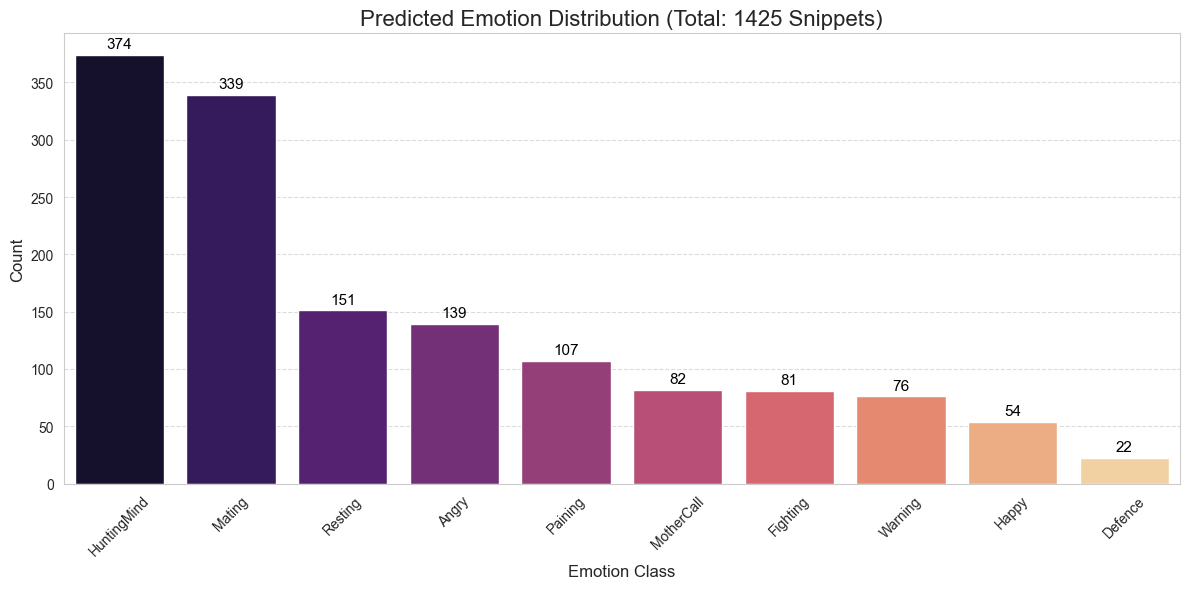

In [130]:
# 1. Map the numeric predictions to their string labels
predicted_labels = [idx_to_class[pred] for pred in all_predictions]

# 2. Create a DataFrame for easy plotting
df_preds = pd.DataFrame({
    'emotion': predicted_labels,
    'confidence': [float(np.max(prob)) for prob in all_probabilities]
})

# 3. Plot the Distribution
plt.figure(figsize=(12, 6))

# We sort by count to make the "dominant" emotions stand out
order = df_preds['emotion'].value_counts().index
ax = sns.countplot(data=df_preds, x='emotion', order=order, palette='magma')

# Add total counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title(f'Predicted Emotion Distribution (Total: {len(df_preds)} Snippets)', fontsize=16)
plt.xlabel('Emotion Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_78671/935029384.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_probs, x='Emotion', y='Confidence', order=class_order, palette='viridis')


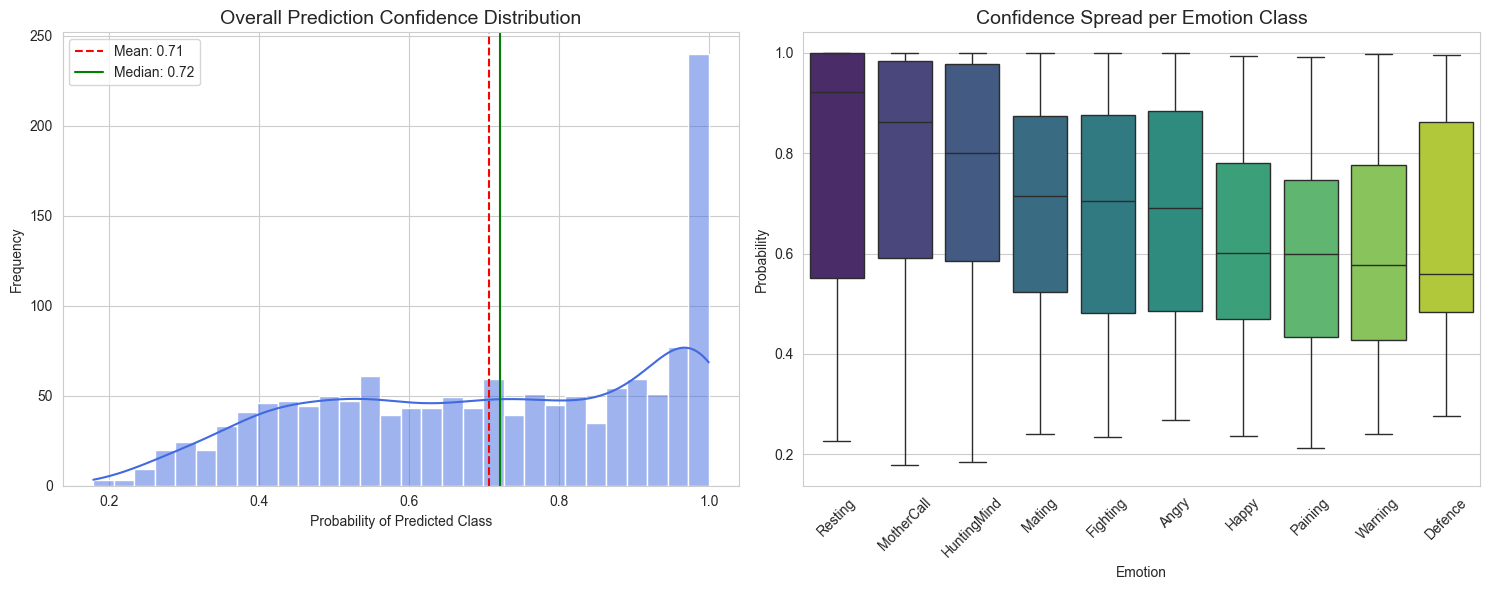

In [131]:
# 1. Prepare the data
# Extract the maximum probability (confidence) for each prediction
confidences = [float(np.max(prob)) for prob in all_probabilities]
labels = [idx_to_class[pred] for pred in all_predictions]

df_probs = pd.DataFrame({
    'Emotion': labels,
    'Confidence': confidences
})

# 2. Create the Visualizations
plt.figure(figsize=(15, 6))

# Plot A: Overall Confidence Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_probs['Confidence'], bins=30, kde=True, color='royalblue')
plt.axvline(df_probs['Confidence'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df_probs['Confidence'].mean():.2f}")
plt.axvline(df_probs['Confidence'].median(), color='green', linestyle='-', 
            label=f"Median: {df_probs['Confidence'].median():.2f}")
plt.title('Overall Prediction Confidence Distribution', fontsize=14)
plt.xlabel('Probability of Predicted Class')
plt.ylabel('Frequency')
plt.legend()

# Plot B: Confidence spread per Class (Boxplot)
plt.subplot(1, 2, 2)
# Sorting classes by their median confidence for better readability
class_order = df_probs.groupby('Emotion')['Confidence'].median().sort_values(ascending=False).index
sns.boxplot(data=df_probs, x='Emotion', y='Confidence', order=class_order, palette='viridis')
plt.xticks(rotation=45)
plt.title('Confidence Spread per Emotion Class', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Probability')

plt.tight_layout()
plt.show()

In [132]:
# Note: Use the inference_loader we set up (the one with the dummy labels)
embeddings_2048, _ = get_embeddings(model, inference_loader_chosen, device=device)

Extracting 2048-D embeddings from the CNN14 backbone...


In [133]:
predicted_emotions = [p for p in all_predictions]
confidences = [float(np.max(prob)) for prob in all_probabilities]

In [134]:
print(f"✅ Features ({embeddings_2048.shape}) and Labels ({len(predicted_emotions)}) ready.")

✅ Features ((1425, 2048)) and Labels (1425) ready.



Running cluster analysis on 1425 samples...

Cluster Quality Metrics (computed in 2048-D space)
--------------------------------------------------
Silhouette Score:           -0.0192  (↑ better, max=1)
Davies-Bouldin Index:       3.5333  (↓ better)
Calinski-Harabasz Score:    22.43  (↑ better)

Per-Class Mean Silhouette:
Angry           : -0.0309
Defence         : -0.1995
Fighting        : -0.1146
Happy           : -0.0227
HuntingMind     : -0.1082
Mating          : 0.1661
MotherCall      : -0.0679
Paining         : 0.0160
Resting         : -0.0865

Running t-SNE projection...


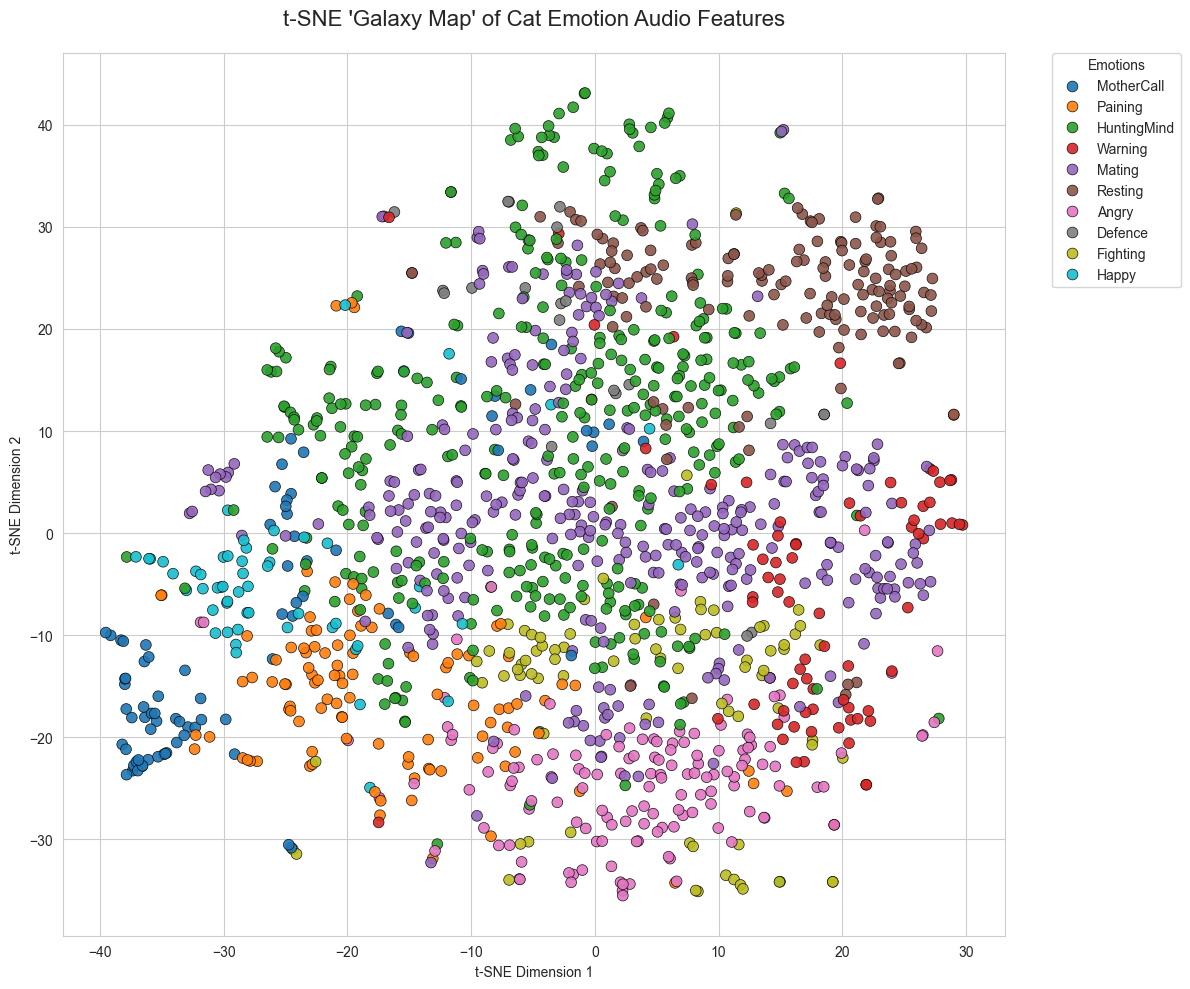

In [135]:
plot_tsne_galaxy_map(embeddings_2048, predicted_emotions, idx_to_class)

# Count Frames to Make Smart Sampling 

In [8]:
import os
import cv2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

In [9]:
# Configuration
VIDEO_FOLDER = 'dataset_snippets'
EXTENSIONS = ('.mp4')

🔍 Performing 'Hard Count' on dataset_snippets...


Actually Counting Frames:   6%|▌         | 138/2361 [00:08<01:35, 23.33it/s][h264 @ 0x12d29e960] mmco: unref short failure
[h264 @ 0x12d29e960] mmco: unref short failure
Actually Counting Frames:  36%|███▋      | 856/2361 [00:42<01:08, 21.98it/s][h264 @ 0x106625930] mmco: unref short failure
[h264 @ 0x106625930] mmco: unref short failure
Actually Counting Frames:  38%|███▊      | 906/2361 [00:44<01:15, 19.35it/s][h264 @ 0x169f48500] mmco: unref short failure
[h264 @ 0x169f48500] mmco: unref short failure
Actually Counting Frames:  44%|████▍     | 1035/2361 [00:53<01:17, 17.17it/s][h264 @ 0x12e0d2ae0] mmco: unref short failure
[h264 @ 0x12e0d2ae0] mmco: unref short failure
Actually Counting Frames:  45%|████▌     | 1074/2361 [00:56<01:34, 13.62it/s][h264 @ 0x106623e10] mmco: unref short failure
[h264 @ 0x12e0d7970] mmco: unref short failure
[h264 @ 0x12e0d7970] mmco: unref short failure
Actually Counting Frames:  47%|████▋     | 1114/2361 [00:59<01:36, 12.89it/s][h264 @ 0x1065210e0] mmc


📊 ACCURATE DATASET STATISTICS
Avg Duration:   5.78s
5th %tile:      3.27s
95th %tile:     7.07s
Min / Max:      3.00s / 7.27s


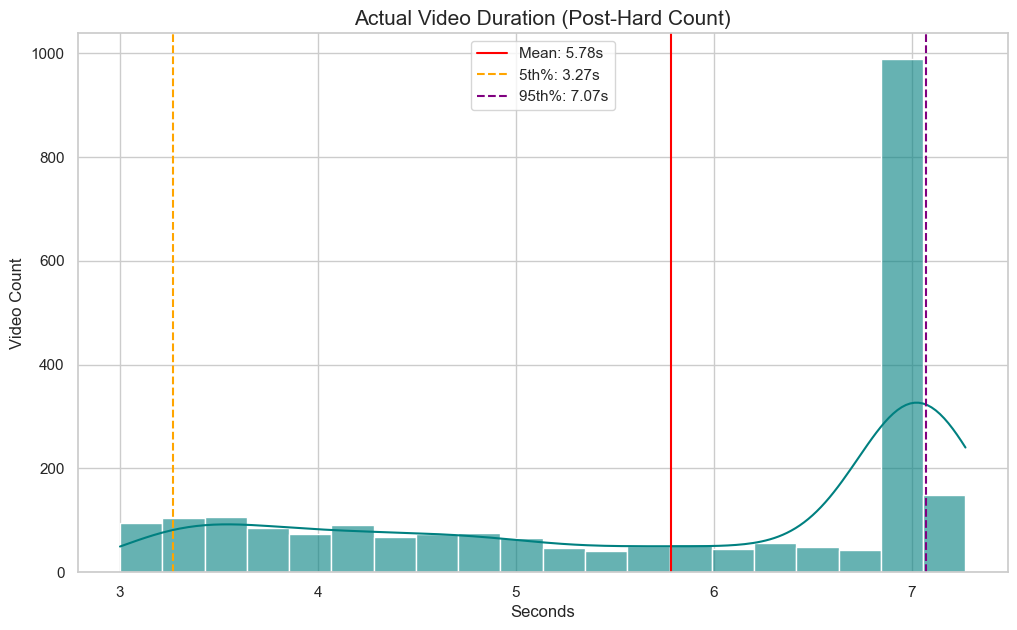

In [10]:
video_data = []

print(f"🔍 Performing 'Hard Count' on {VIDEO_FOLDER}...")

files = [f for f in os.listdir(VIDEO_FOLDER) if f.lower().endswith(EXTENSIONS)]

for filename in tqdm(files, desc="Actually Counting Frames"):
    path = os.path.join(VIDEO_FOLDER, filename)
    cap = cv2.VideoCapture(path)
    
    if not cap.isOpened():
        continue

    # --- THE HARD COUNT ---
    # We physically step through the frames to find the real end
    true_frame_count = 0
    while True:
        # grab() is much faster than read() because it doesn't decode the image
        success = cap.grab() 
        if not success:
            break
        true_frame_count += 1
    
    # Get FPS (OpenCV is usually okay at this, but we'll use it to calc duration)
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = true_frame_count / fps if fps > 0 else 0
    
    video_data.append({
        'filename': filename,
        'true_frames': true_frame_count,
        'fps': round(fps, 2),
        'duration_sec': round(duration, 2)
    })
    cap.release()

df = pd.DataFrame(video_data)

# --- Statistics & Plotting ---
if not df.empty:
    p05 = df['duration_sec'].quantile(0.05)
    p95 = df['duration_sec'].quantile(0.95)
    mean_dur = df['duration_sec'].mean()

    print("\n" + "="*35)
    print("📊 ACCURATE DATASET STATISTICS")
    print("="*35)
    print(f"Avg Duration:   {mean_dur:.2f}s")
    print(f"5th %tile:      {p05:.2f}s")
    print(f"95th %tile:     {p95:.2f}s")
    print(f"Min / Max:      {df['duration_sec'].min():.2f}s / {df['duration_sec'].max():.2f}s")
    print("="*35)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))
    
    # Plotting Duration (Seconds) instead of frame count for clarity
    sns.histplot(df['duration_sec'], kde=True, color="teal", bins=20, alpha=0.6)
    
    plt.axvline(mean_dur, color='red', label=f'Mean: {mean_dur:.2f}s')
    plt.axvline(p05, color='orange', linestyle='--', label=f'5th%: {p05:.2f}s')
    plt.axvline(p95, color='purple', linestyle='--', label=f'95th%: {p95:.2f}s')
    
    plt.title('Actual Video Duration (Post-Hard Count)', fontsize=15)
    plt.xlabel('Seconds')
    plt.ylabel('Video Count')
    plt.legend()
    plt.show()

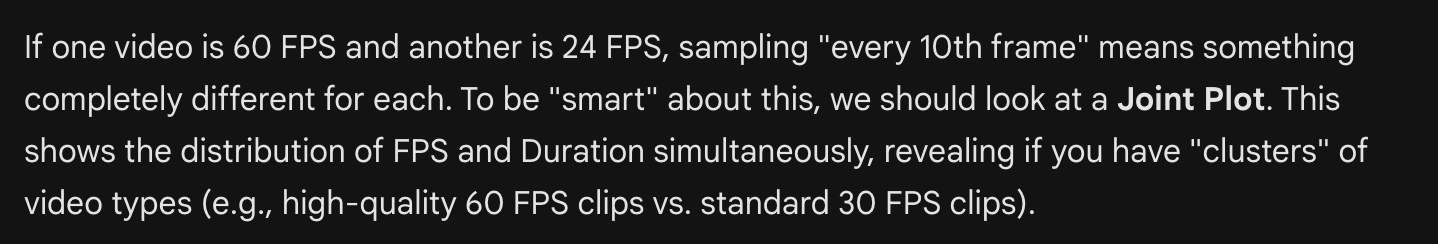

/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_78950/976453301.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='fps_rounded', ax=axes[0], palette="viridis")


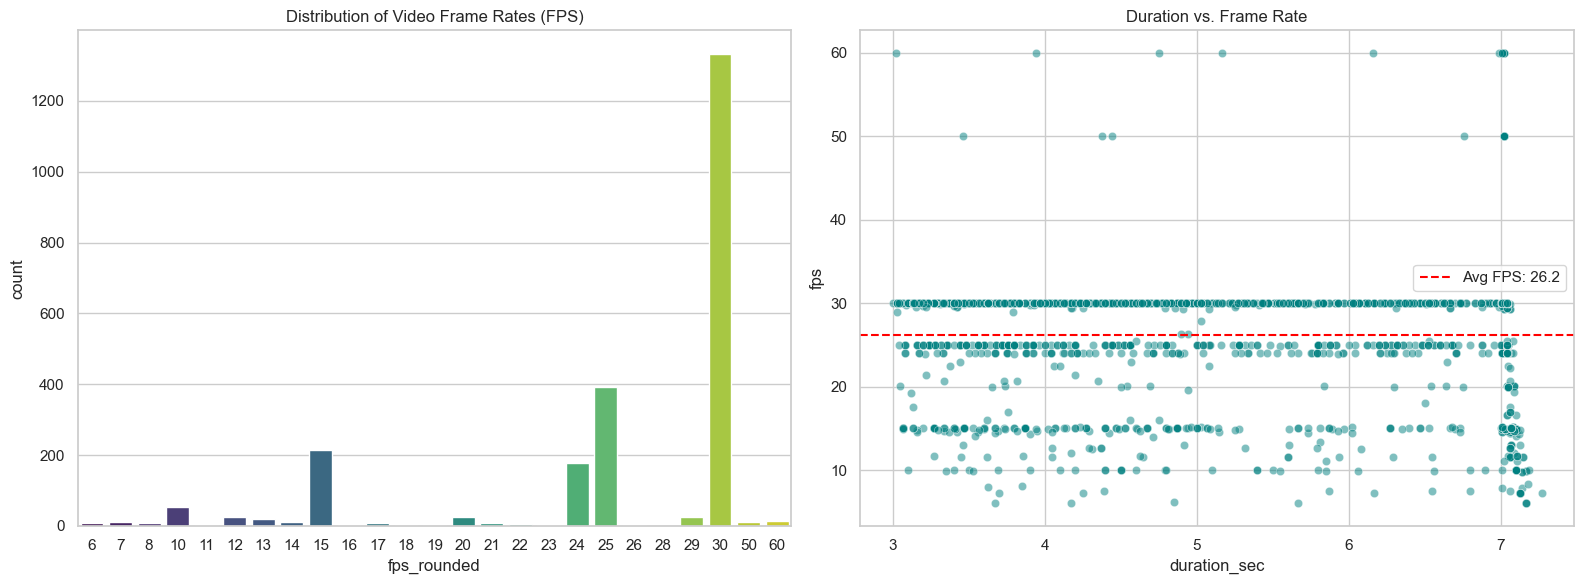

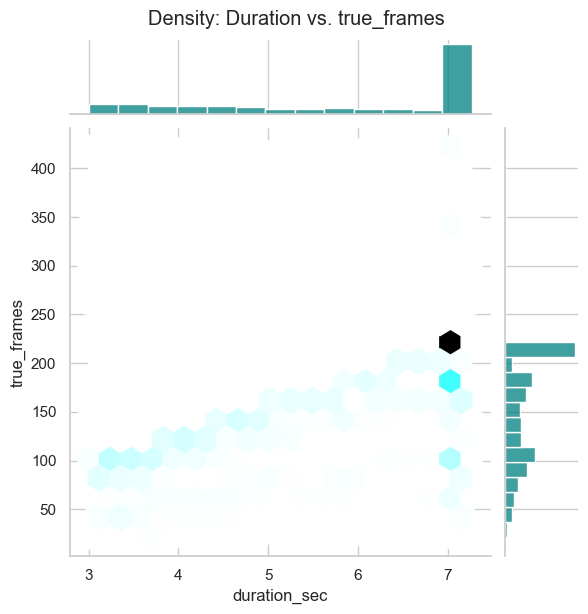


🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀 LLM PROMPT SNIPPET 🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
I am training a cat video classifier using CLIP embeddings. Here is my dataset profile:
{
    "dataset_size": 2361,
    "duration": {
        "mean": 5.78,
        "median": 6.61,
        "p05": 3.27,
        "p95": 7.07,
        "min": 3.0,
        "max": 7.27
    },
    "fps_clusters": {
        "30": 1332,
        "25": 393,
        "15": 213,
        "24": 177,
        "10": 53,
        "12": 25,
        "29": 25,
        "20": 25,
        "13": 19,
        "60": 13,
        "50": 12,
        "14": 11,
        "7": 11,
        "8": 8,
        "17": 7,
        "6": 7,
        "21": 7,
        "22": 6,
        "18": 3,
        "11": 3,
        "16": 3,
        "23": 3,
        "19": 2,
        "26": 2,
        "28": 1
    },
    "total_frames": 358603,
    "avg_frames_per_video": 151.9
}


In [14]:
import json

def plot_sampling_insights(df):
    sns.set_theme(style="whitegrid")
    
    # 1. Visualization Code (Same as before)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    df['fps_rounded'] = df['fps'].round().astype(int)
    sns.countplot(data=df, x='fps_rounded', ax=axes[0], palette="viridis")
    axes[0].set_title('Distribution of Video Frame Rates (FPS)')

    sns.scatterplot(data=df, x='duration_sec', y='fps', alpha=0.5, ax=axes[1], color='teal')
    axes[1].set_title('Duration vs. Frame Rate')
    avg_fps = df['fps'].mean()
    axes[1].axhline(avg_fps, color='red', linestyle='--', label=f'Avg FPS: {avg_fps:.1f}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    y_col = 'true_frames' if 'true_frames' in df.columns else 'frames'
    g = sns.jointplot(data=df, x='duration_sec', y=y_col, kind="hex", color="teal")
    g.fig.suptitle(f"Density: Duration vs. {y_col}", y=1.02)
    plt.show()

    # --- 2. LLM-READY STATS EXTRACTION ---
    stats_summary = {
        "dataset_size": len(df),
        "duration": {
            "mean": round(df['duration_sec'].mean(), 2),
            "median": round(df['duration_sec'].median(), 2),
            "p05": round(df['duration_sec'].quantile(0.05), 2),
            "p95": round(df['duration_sec'].quantile(0.95), 2),
            "min": round(df['duration_sec'].min(), 2),
            "max": round(df['duration_sec'].max(), 2)
        },
        "fps_clusters": df['fps_rounded'].value_counts().to_dict(),
        "total_frames": int(df[y_col].sum()),
        "avg_frames_per_video": round(df[y_col].mean(), 1)
    }

    print("\n" + "🚀" * 10 + " LLM PROMPT SNIPPET " + "🚀" * 10)
    print("I am training a cat video classifier using CLIP embeddings. Here is my dataset profile:")
    print(json.dumps(stats_summary, indent=4))
    print("=" * 40)
    
    return stats_summary

# Execute
llm_data = plot_sampling_insights(df)

In [13]:
# Filter the DataFrame for videos longer than 7.5 seconds
outliers = df[df['duration_sec'] > 7.5].sort_values(by='duration_sec', ascending=False)

if not outliers.empty:
    print(f"🚩 Found {len(outliers)} videos that report being > 7.5s:")
    print(outliers[['filename', 'duration_sec', 'frames', 'fps']].head(10))
else:
    print("✅ No videos actually exceed 7.5s in the raw data. The plot curve was just 'smearing'.")

✅ No videos actually exceed 7.5s in the raw data. The plot curve was just 'smearing'.


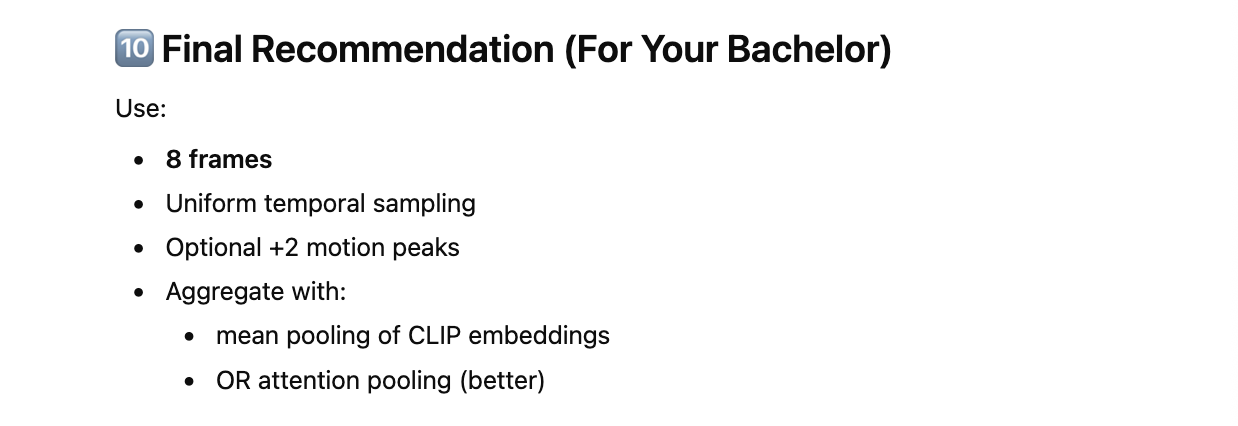

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def sample_frames_temporal(
    video_path: str,
    num_frames: int = 8,
    start_ratio: float = 0.1,
    end_ratio: float = 0.9
):
    """
    Samples frames using temporal percentage positions.
    
    Args:
        video_path: path to video file
        num_frames: number of frames to sample
        start_ratio: where sampling starts (0-1)
        end_ratio: where sampling ends (0-1)
        
    Returns:
        frames (list of np.ndarray in RGB)
    """
    
    video_path = str(video_path)
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames == 0:
        raise ValueError("Video has 0 frames.")
    
    # Generate evenly spaced temporal positions
    positions = np.linspace(start_ratio, end_ratio, num_frames)
    frame_indices = (positions * (total_frames - 1)).astype(int)
    
    frames = []
    
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        
        if not ret:
            continue
        
        # Convert BGR → RGB for matplotlib / CLIP
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    
    cap.release()
    
    return frames


def show_sampled_frames(frames, title=None):
    """
    Displays sampled frames nicely in a row.
    """
    n = len(frames)
    
    plt.figure(figsize=(3 * n, 4))
    
    for i, frame in enumerate(frames):
        plt.subplot(1, n, i + 1)
        plt.imshow(frame)
        plt.axis("off")
        plt.title(f"Frame {i+1}")
    
    if title:
        plt.suptitle(title, fontsize=14)
    
    plt.tight_layout()
    plt.show()

Random video path: dataset_snippets/cat, cat, beaby_snip_0.mp4


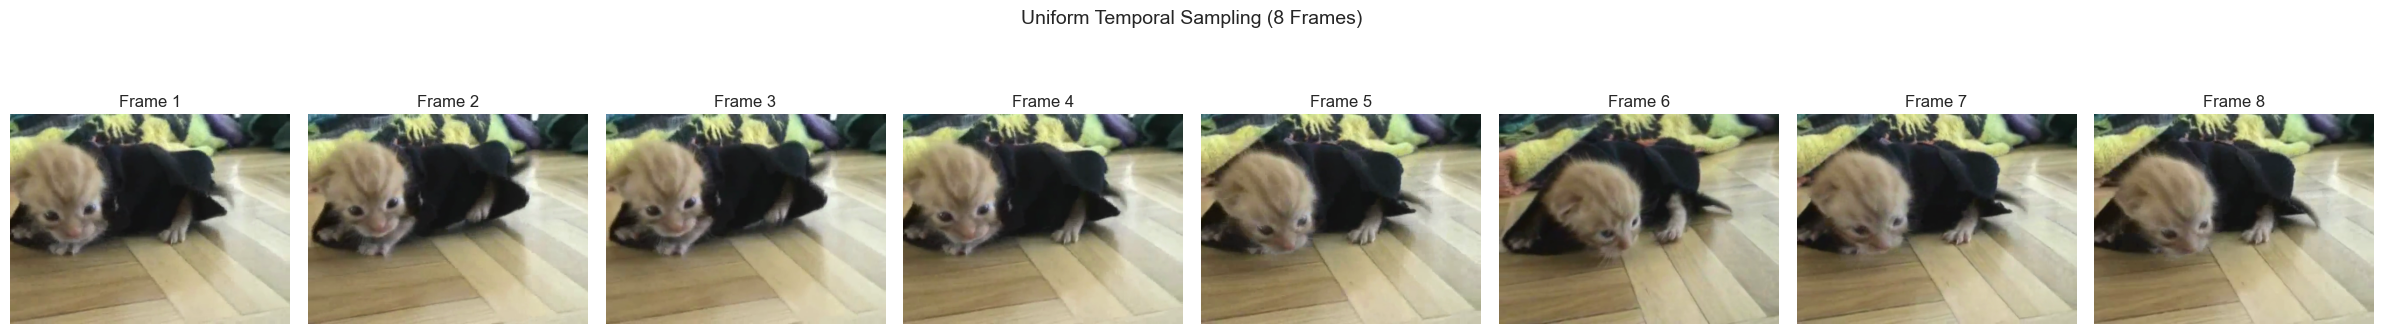

In [189]:
random_video_path = f"dataset_snippets/{df.filename.sample().values[0]}"
print(f"Random video path: {random_video_path}")

frames = sample_frames_temporal(random_video_path, num_frames=8)

show_sampled_frames(frames, title="Uniform Temporal Sampling (8 Frames)")

In [76]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def analyze_temporal_sampling_sns(
    video_path: str,
    num_frames: int = 8,
    start_ratio: float = 0.1,
    end_ratio: float = 0.9,
    show_sampled_frames: bool = True
):
    """
    Visualizes:
    - Frame-to-frame difference across entire video (Seaborn style)
    - Which frames temporal sampling selects
    """

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 1:
        raise ValueError("Video too short.")

    frames_gray = []

    # --- Read all frames ---
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames_gray.append(gray)

    cap.release()

    frames_gray = np.array(frames_gray)
    total_frames = len(frames_gray)

    # --- Compute frame-to-frame differences ---
    diffs = np.mean(
        np.abs(
            frames_gray[1:].astype(np.float32)
            - frames_gray[:-1].astype(np.float32)
        ),
        axis=(1, 2)
    )

    # --- Temporal sampling indices ---
    positions = np.linspace(start_ratio, end_ratio, num_frames)
    sampled_indices = (positions * (total_frames - 1)).astype(int)

    # --- Seaborn style ---
    sns.set(style="whitegrid")
    plt.figure(figsize=(14, 5))

    sns.lineplot(
        x=np.arange(len(diffs)),
        y=diffs,
        linewidth=2
    )

    # Mark sampled frames
    for idx in sampled_indices:
        plt.axvline(x=idx, linestyle="--", alpha=0.6)

    plt.title("Frame Difference Over Time\nDashed lines = Temporal Sampling Positions")
    plt.xlabel("Frame Index")
    plt.ylabel("Mean Absolute Pixel Difference")
    plt.tight_layout()
    plt.show()

    # --- Show sampled frames ---
    if show_sampled_frames:
        cap = cv2.VideoCapture(video_path)
        sampled_frames = []

        for idx in sampled_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                sampled_frames.append(frame)

        cap.release()

        n = len(sampled_frames)
        plt.figure(figsize=(3 * n, 4))

        for i, frame in enumerate(sampled_frames):
            plt.subplot(1, n, i + 1)
            plt.imshow(frame)
            plt.axis("off")
            plt.title(f"Idx {sampled_indices[i]}")

        plt.suptitle("Sampled Frames")
        plt.tight_layout()
        plt.show()

Random video path: dataset_snippets/猫のフーガ 努力呼吸の様子_snip_1.mp4


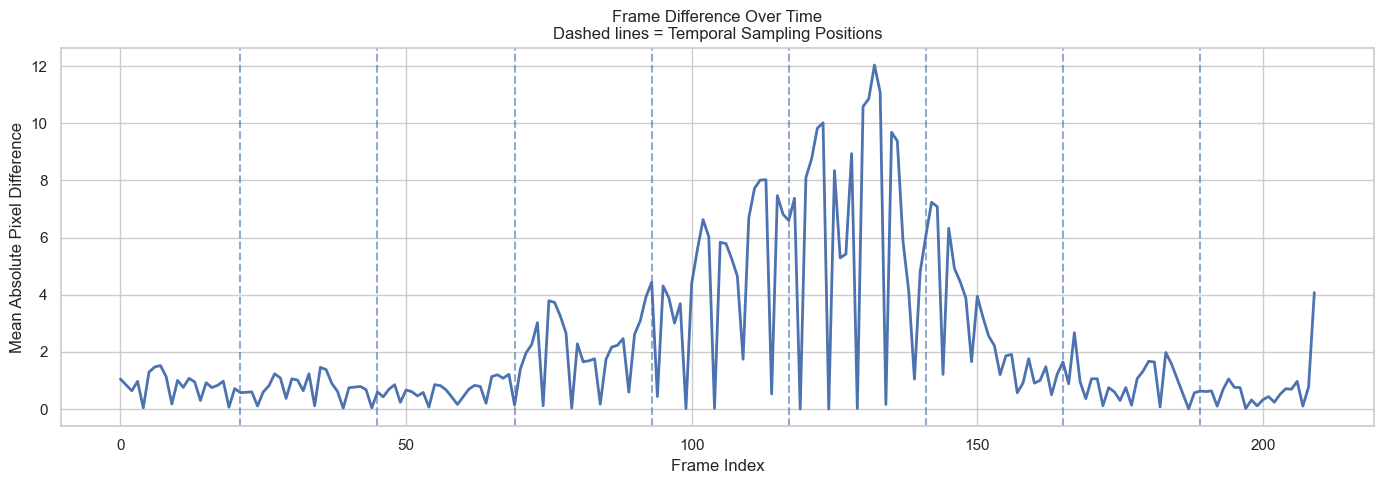

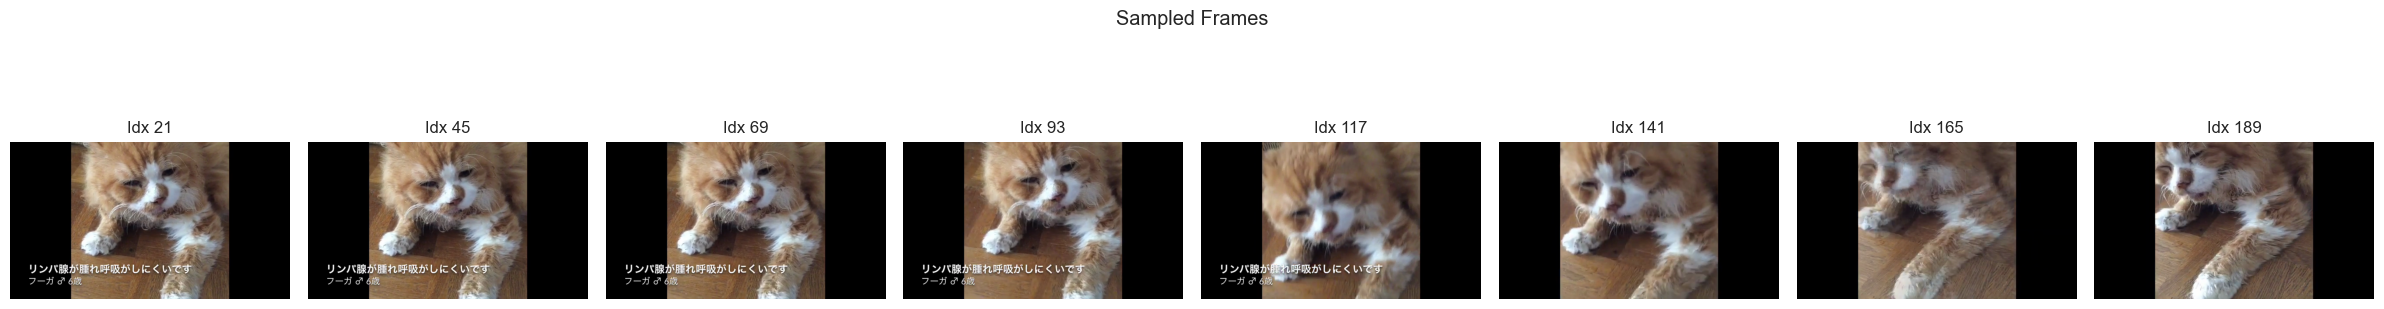

In [100]:
random_video_path = f"dataset_snippets/{df.filename.sample().values[0]}"
print(f"Random video path: {random_video_path}")

analyze_temporal_sampling_sns(random_video_path, num_frames=8, show_sampled_frames=True)

### Selecting top K% different frames and embedding them

In [101]:
import cv2
import numpy as np


def compute_frame_differences(video_path: str):
    """
    Computes mean absolute pixel difference between adjacent frames.

    Args:
        video_path: path to video file

    Returns:
        diffs: list of float
               diffs[i] = difference between frame i+1 and frame i
        total_frames: total number of frames in video
    """

    video_path = str(video_path)
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    frames_gray = []

    # Read all frames in grayscale
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames_gray.append(gray)

    cap.release()

    total_frames = len(frames_gray)

    if total_frames < 2:
        raise ValueError("Video too short to compute differences.")

    frames_gray = np.array(frames_gray, dtype=np.float32)

    # Compute adjacent differences
    diffs = np.mean(
        np.abs(frames_gray[1:] - frames_gray[:-1]),
        axis=(1, 2)
    )

    return diffs.tolist(), total_frames

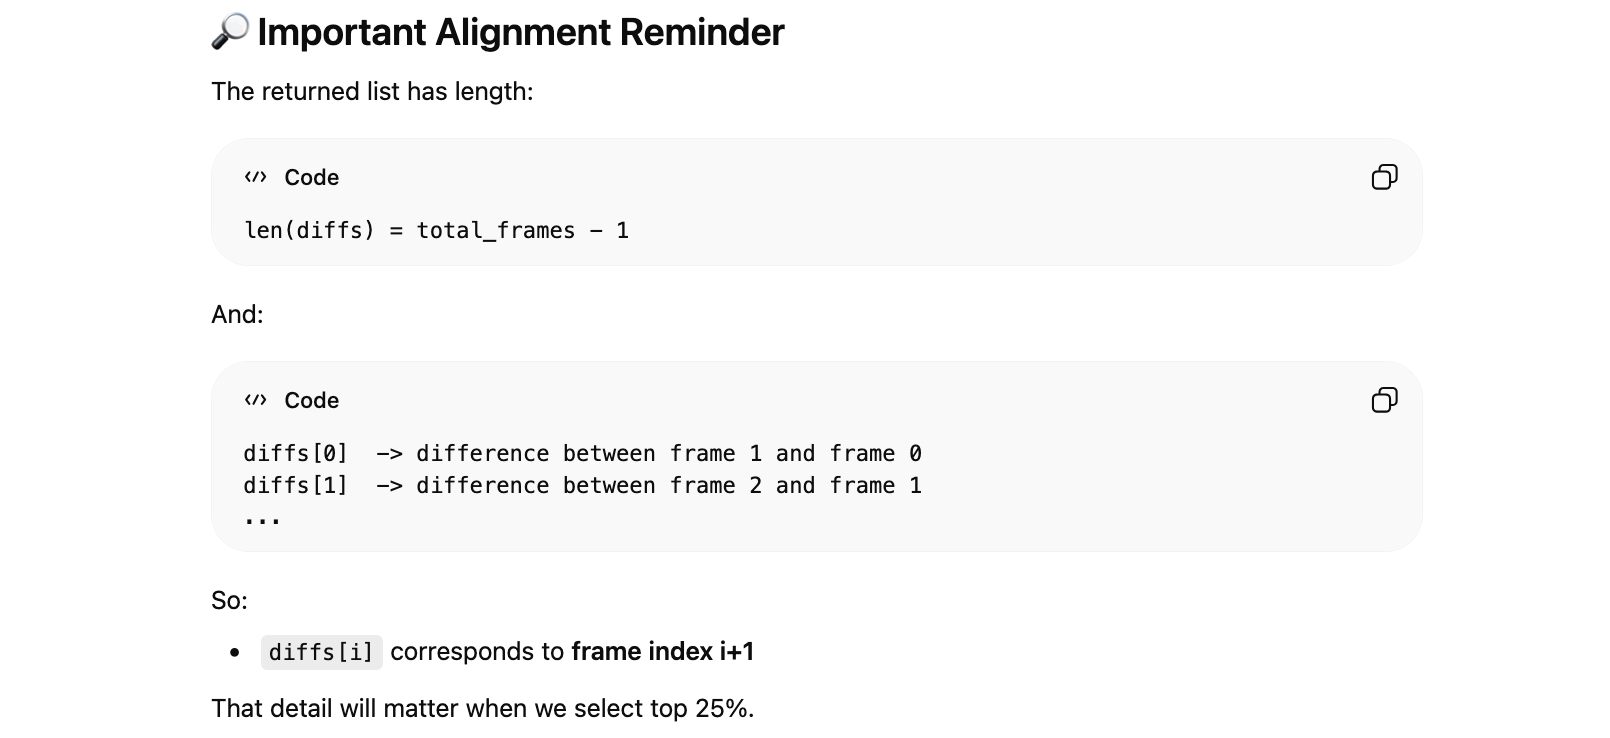

In [136]:
diffs, total_frames = compute_frame_differences(f"dataset_snippets/{df.filename.sample().values[0]}")
diffs[:3], total_frames

([5.677525997161865, 5.33760404586792, 4.993945121765137], 138)

In [137]:
import numpy as np
import math


def select_top_motion_ratio(diffs, ratio: float):
    """
    Selects top motion frames based on percentage ratio.

    Args:
        diffs: list or np.ndarray of frame-to-frame differences
               diffs[i] = difference between frame i+1 and frame i
        ratio: float in (0, 1], percentage of frames to keep

    Returns:
        selected_indices: sorted list of frame indices (int)
                          referring to original video frame indices
    """

    diffs = np.array(diffs)

    if len(diffs) == 0:
        raise ValueError("Empty diffs array.")

    if not (0 < ratio <= 1):
        raise ValueError("ratio must be in (0, 1].")

    # Number of frames to select
    k = math.ceil(len(diffs) * ratio)

    # Partial selection (efficient)
    top_k_diff_indices = np.argpartition(diffs, -k)[-k:]

    # Convert diff index -> actual frame index
    # diff[i] corresponds to frame (i+1)
    frame_indices = top_k_diff_indices + 1

    # Sort temporally
    frame_indices = np.sort(frame_indices)

    return frame_indices.tolist()

In [154]:
K = 0.25 # we will keep the top 50% most "motiony" frames

In [155]:
top_k_indices = select_top_motion_ratio(diffs, K)
top_k_indices[:3], len(top_k_indices), len(diffs)

([10, 12, 14], 53, 209)

In [156]:
for index in range(5):
    print(diffs[top_k_indices[index] - 1], top_k_indices[index])

15.952759742736816 10
18.965763092041016 12
12.691802024841309 14
8.313908576965332 17
18.908220291137695 18


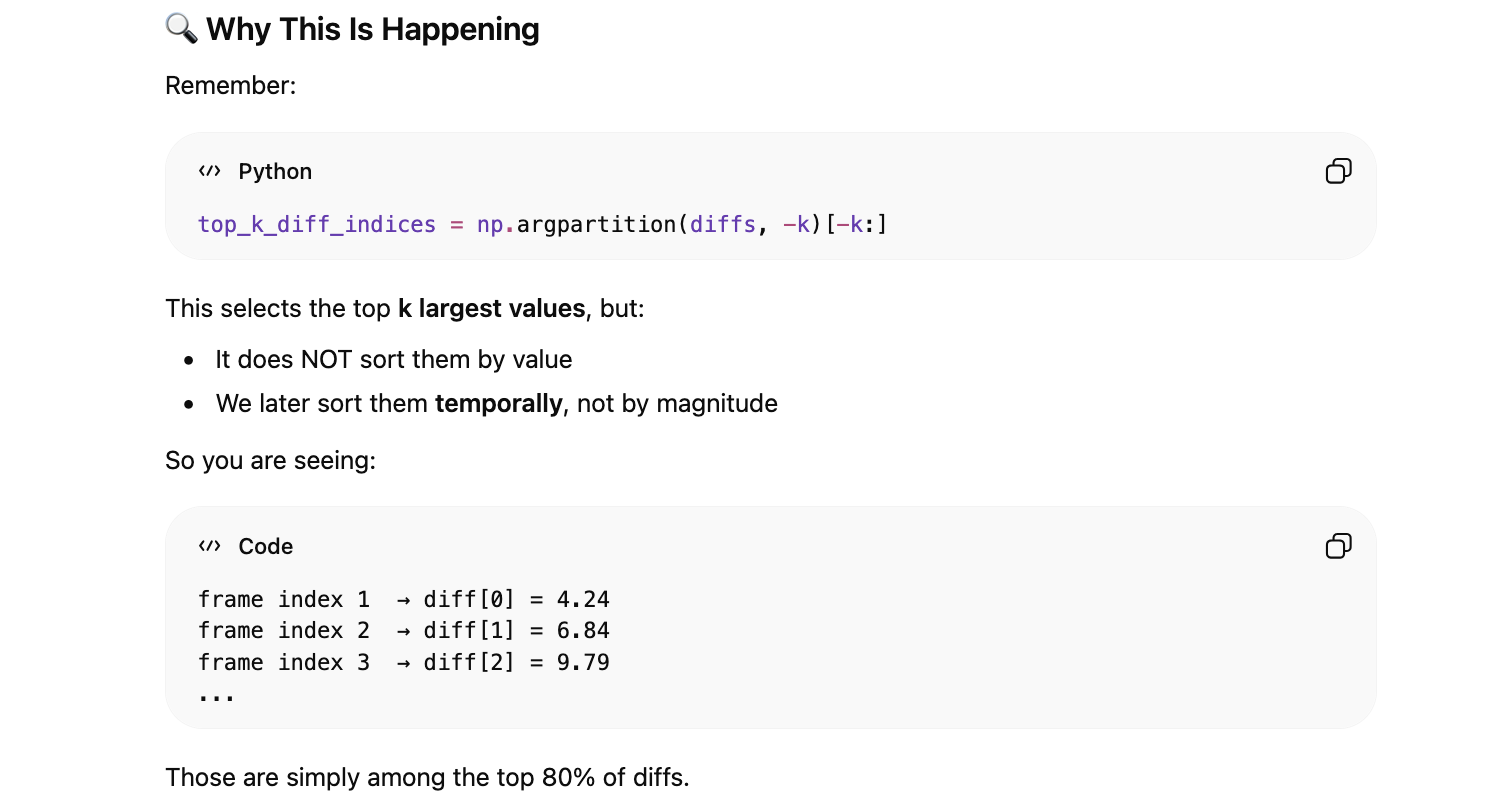

### Now embedding them with CLIP

✅ 1️⃣ Load Frames by Indices (Efficiently)

Important:

Indices must refer to original frame numbers

We assume they are sorted (your previous function already sorts them)

We avoid reading the whole video into memory

In [157]:
import cv2
import numpy as np


def load_frames_by_indices(video_path: str, frame_indices):
    """
    Loads specific frames from a video.

    Args:
        video_path: path to video file
        frame_indices: list of frame indices (int)

    Returns:
        frames: list of RGB numpy arrays
    """

    video_path = str(video_path)
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()

        if not ret:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()

    return frames

Random video path: dataset_snippets/peaches newborn kittens_snip_2.mp4


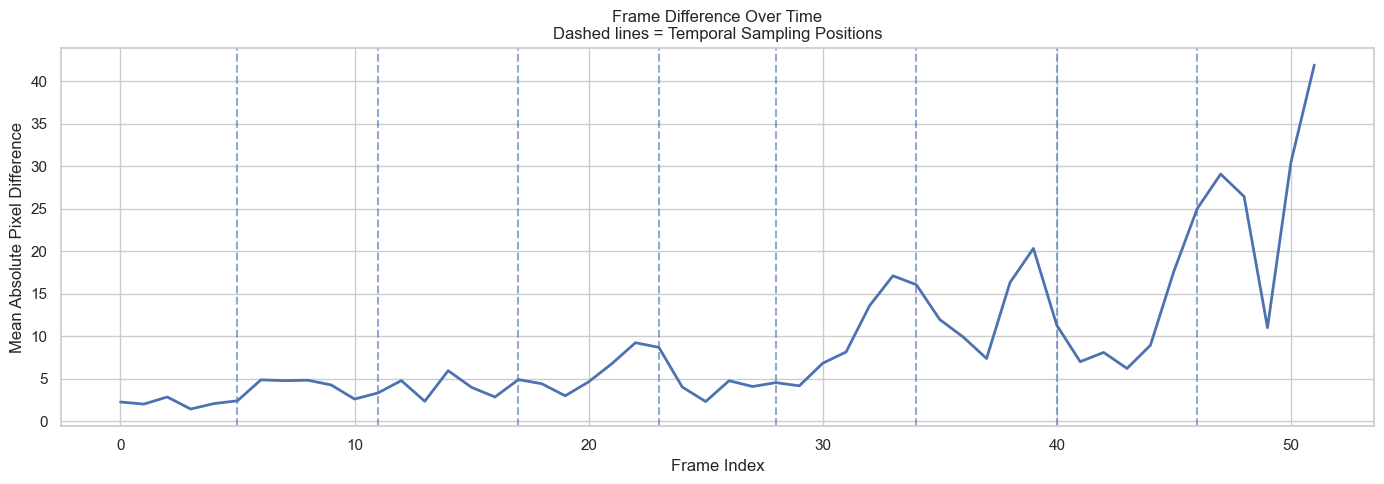

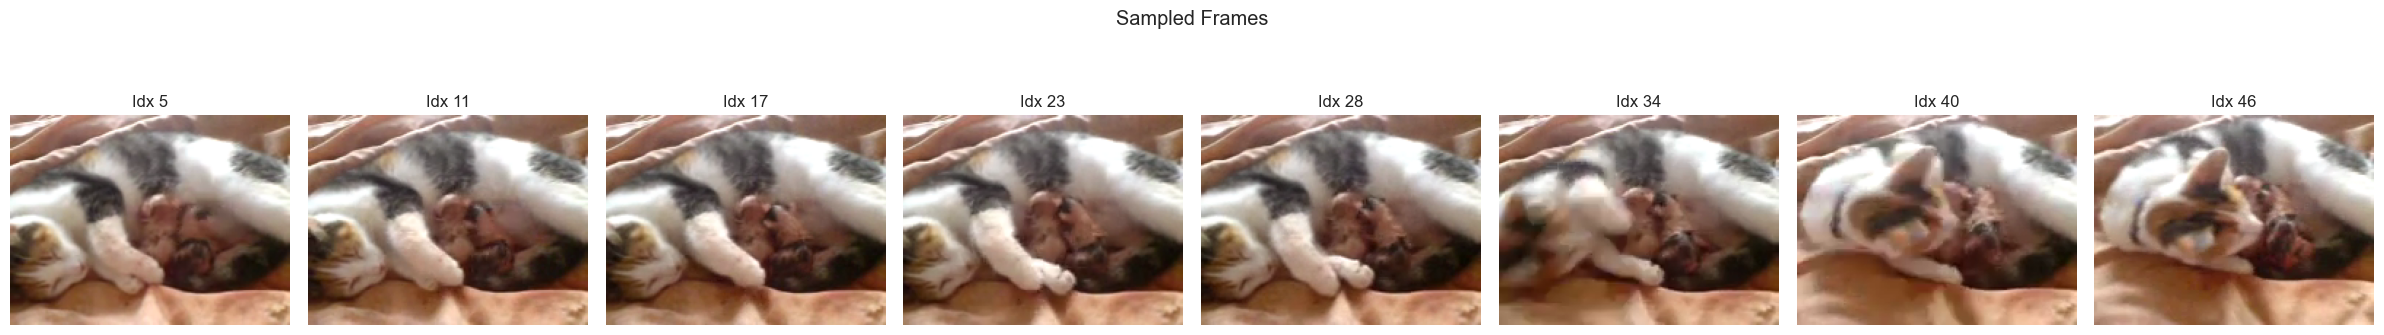

In [158]:
random_video_path = f"dataset_snippets/{df.filename.sample().values[0]}"
print(f"Random video path: {random_video_path}")

analyze_temporal_sampling_sns(random_video_path, num_frames=8, show_sampled_frames=True)

diffs, total_frames = compute_frame_differences(f"dataset_snippets/{df.filename.sample().values[0]}")

top_k_indices = select_top_motion_ratio(diffs, K)

5 53


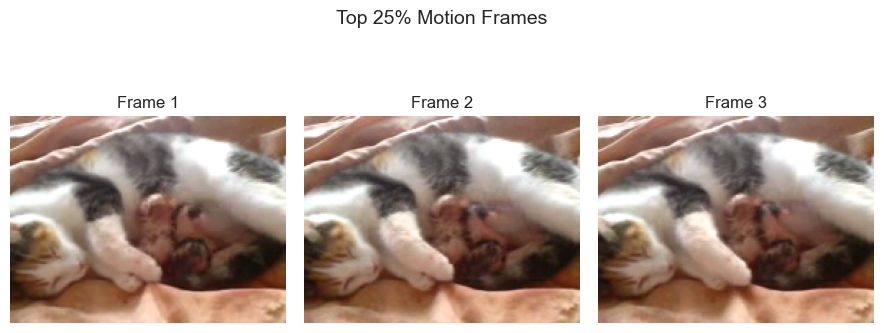

In [ ]:
loaded_frames = load_frames_by_indices(random_video_path, top_k_indices)
print(len(loaded_frames), len(top_k_indices))
show_sampled_frames(loaded_frames[:3], title=f"Top {K*100:.0f}% Motion Frames")

In [162]:
import torch
import open_clip

device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"

# Updated for ViT-B-16 with the correct LAION tag
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-16', 
    pretrained='laion2b_s34b_b88k'
)
model = model.to(device)
model.eval()

print(f"Model loaded on {device}!")
print(f"Input resolution: {model.visual.image_size}")
print(f"Embedding dimension: {model.visual.output_dim}") # Should be 512

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded on mps!
Input resolution: (224, 224)
Embedding dimension: 512


In [163]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

def get_frame_embeddings(frames: list, model, preprocess, device, batch_size: int = 32):
    """
    Computes OpenCLIP embeddings for a list of RGB frames.

    Args:
        frames: list of RGB numpy arrays (output from load_frames_by_indices)
        model: loaded OpenCLIP model
        preprocess: OpenCLIP image transform pipeline
        device: torch device (cpu, cuda, or mps)
        batch_size: number of frames to process at once to avoid Out-Of-Memory errors

    Returns:
        torch.Tensor: Normalized embeddings of shape (N, embedding_dim) on the CPU.
    """
    if not frames:
        print("Warning: Empty frame list provided.")
        return torch.empty((0, model.visual.output_dim))

    all_embeddings = []

    # Disable gradient calculations for inference
    with torch.no_grad():
        for i in range(0, len(frames), batch_size):
            batch_frames = frames[i:i + batch_size]
            
            # 1. Convert NumPy arrays (RGB) to PIL Images
            pil_images = [Image.fromarray(frame) for frame in batch_frames]
            
            # 2. Preprocess and stack into a single tensor
            # preprocess() returns a torch.Tensor for a single image
            tensor_batch = torch.stack([preprocess(img) for img in pil_images])
            
            # 3. Move the batch to the designated device
            tensor_batch = tensor_batch.to(device)
            
            # 4. Extract visual features
            image_features = model.encode_image(tensor_batch)
            
            # 5. Normalize the embeddings (Standard practice for CLIP to compute cosine similarity later)
            image_features = F.normalize(image_features, dim=-1)
            
            # Move back to CPU to free up MPS/GPU memory before the next batch
            all_embeddings.append(image_features.cpu())

    # Concatenate all batches into a single tensor
    return torch.cat(all_embeddings, dim=0)

Random video path: dataset_snippets/Cat trapped (Macka u zamci)_snip_0.mp4


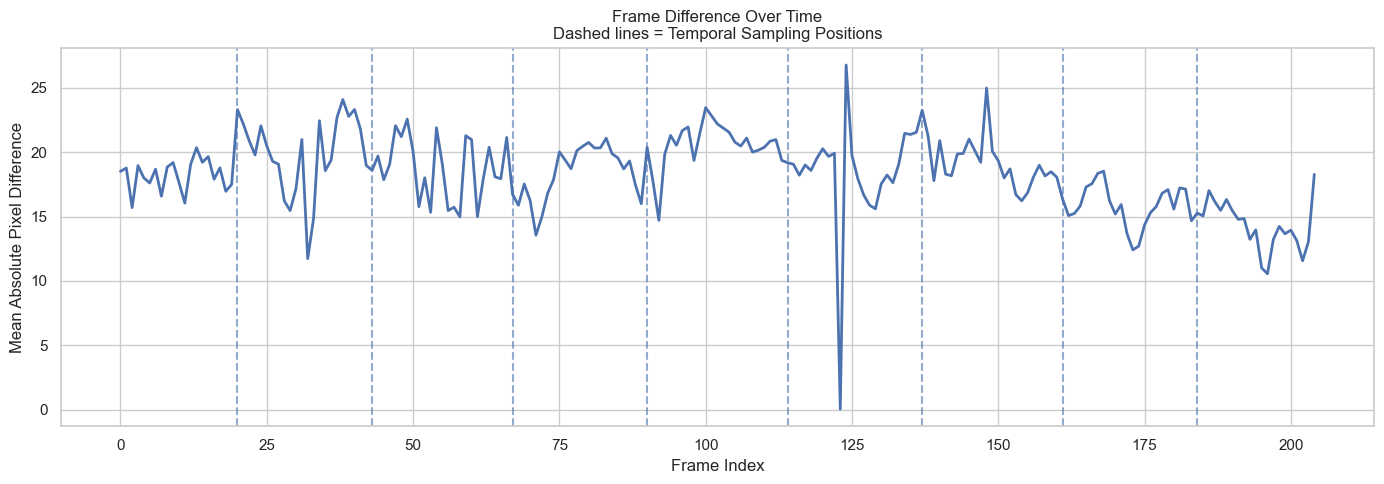

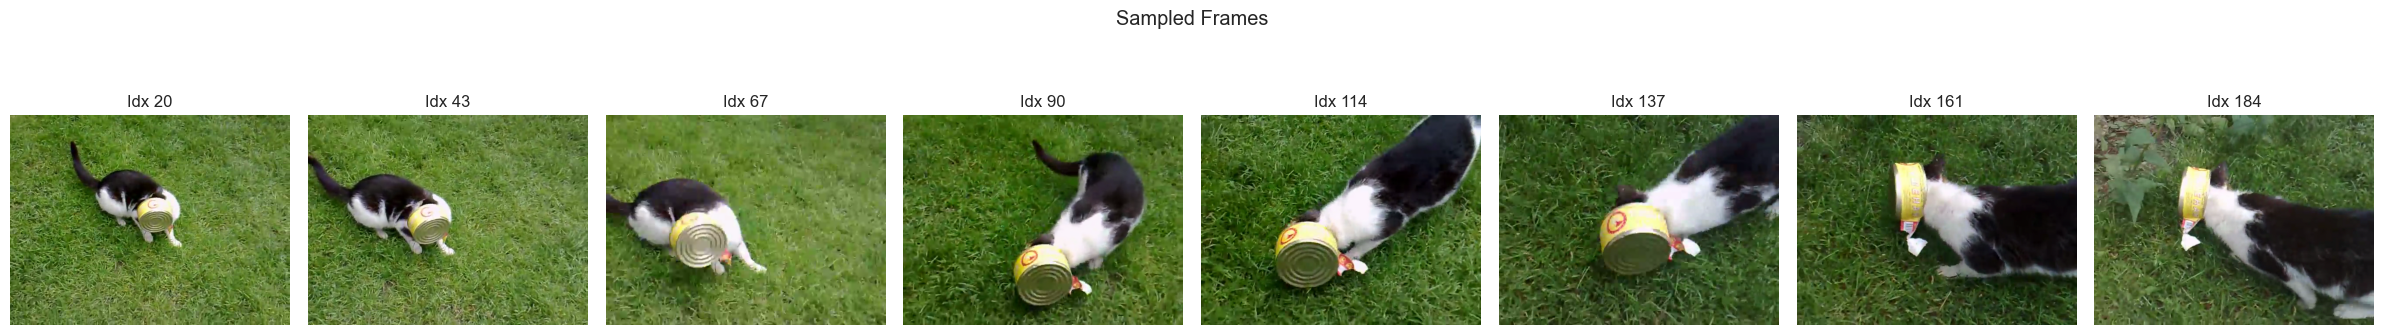

52 52
Successfully processed 52 frames.
Embeddings shape: torch.Size([52, 512])


In [164]:
# 1. Load the frames (assuming you want frames 0, 10, 20, 30)
random_video_path = f"dataset_snippets/{df.filename.sample().values[0]}"
print(f"Random video path: {random_video_path}")

analyze_temporal_sampling_sns(random_video_path, num_frames=8, show_sampled_frames=True)

diffs, total_frames = compute_frame_differences(random_video_path)

top_k_indices = select_top_motion_ratio(diffs, K)

loaded_frames = load_frames_by_indices(random_video_path, top_k_indices)
print(len(loaded_frames), len(top_k_indices))

# 2. Get the embeddings
if loaded_frames:
    embeddings = get_frame_embeddings(loaded_frames, model, preprocess, device, batch_size=16)

    print(f"Successfully processed {len(loaded_frames)} frames.")
    print(f"Embeddings shape: {embeddings.shape}") # Should be (4, 512)
else:
    print("No frames were loaded.")

In [167]:
embeddings.shape

torch.Size([52, 512])

### Clustering them

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def cluster_and_get_center_frames(embeddings, frames, num_clusters=3):
    """
    Clusters frame embeddings using K-Means, plots the 2D PCA projection, 
    and returns the frames closest to the cluster centers.

    Args:
        embeddings: torch.Tensor of shape (N, 512)
        frames: list of original RGB numpy arrays
        num_clusters: number of clusters to form

    Returns:
        center_frames: list of RGB numpy arrays representing the cluster centers
    """
    if len(frames) < num_clusters:
        raise ValueError(f"Number of frames ({len(frames)}) must be >= number of clusters ({num_clusters})")

    # 1. Convert PyTorch tensor to NumPy array
    X = embeddings.cpu().numpy()

    # 2. Perform K-Means clustering
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)
    centroids = kmeans.cluster_centers_

    # 3. Find the actual frame closest to each mathematical centroid
    center_frame_indices = []
    for i in range(num_clusters):
        # Get indices of all frames belonging to cluster i
        cluster_indices = np.where(labels == i)[0]
        cluster_embeddings = X[cluster_indices]
        
        # Calculate Euclidean distance from these points to the centroid
        distances = np.linalg.norm(cluster_embeddings - centroids[i], axis=1)
        
        # Find the index of the closest point within this cluster
        closest_local_idx = np.argmin(distances)
        closest_global_idx = cluster_indices[closest_local_idx]
        
        center_frame_indices.append(closest_global_idx)

    center_frames = [frames[i] for i in center_frame_indices]

    # 4. Dimensionality Reduction for Plotting (512D -> 2D)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    centroids_pca = pca.transform(centroids) # Project centroids into the same 2D space

    # 5. Plot the clusters
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, s=50, label='Frames')
    
    # Plot the mathematical centroids
    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Mathematical Centroids')
    
    # Highlight the actual representative frames
    representative_pca = X_pca[center_frame_indices]
    plt.scatter(representative_pca[:, 0], representative_pca[:, 1], 
                c='none', edgecolors='black', linewidths=2, s=150, label='Actual Center Frames')

    plt.title(f'K-Means Clustering of Video Frames (PCA Projection, k={num_clusters})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.colorbar(scatter, label='Cluster Label')
    plt.show()

    return center_frames, center_frame_indices

Random video path: dataset_snippets/Cat loves eating chicken (猫のおやつはチキン)_snip_8.mp4


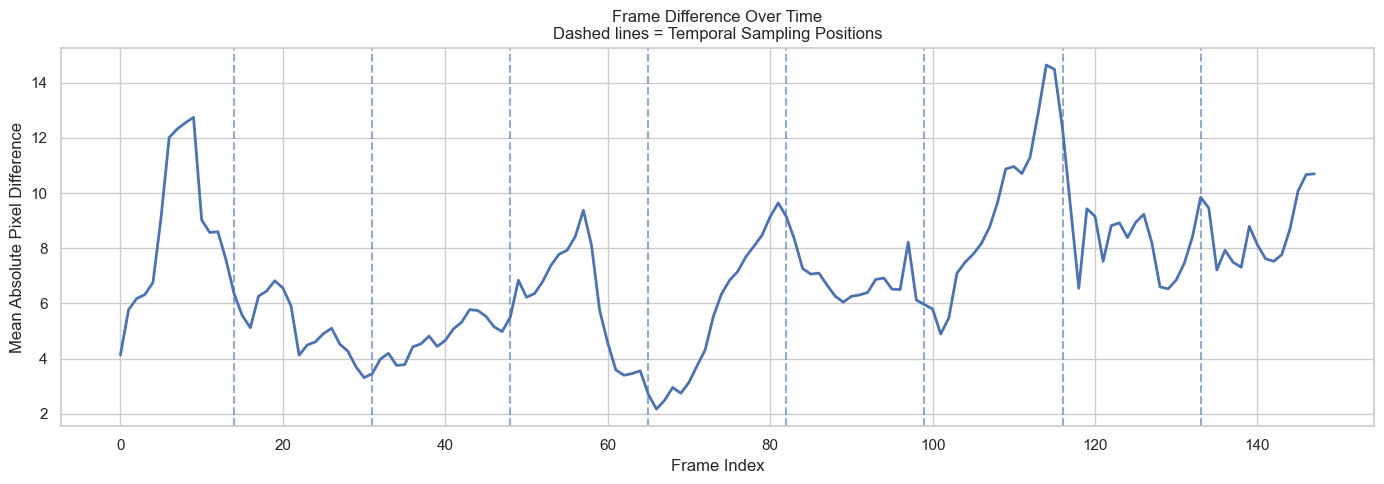

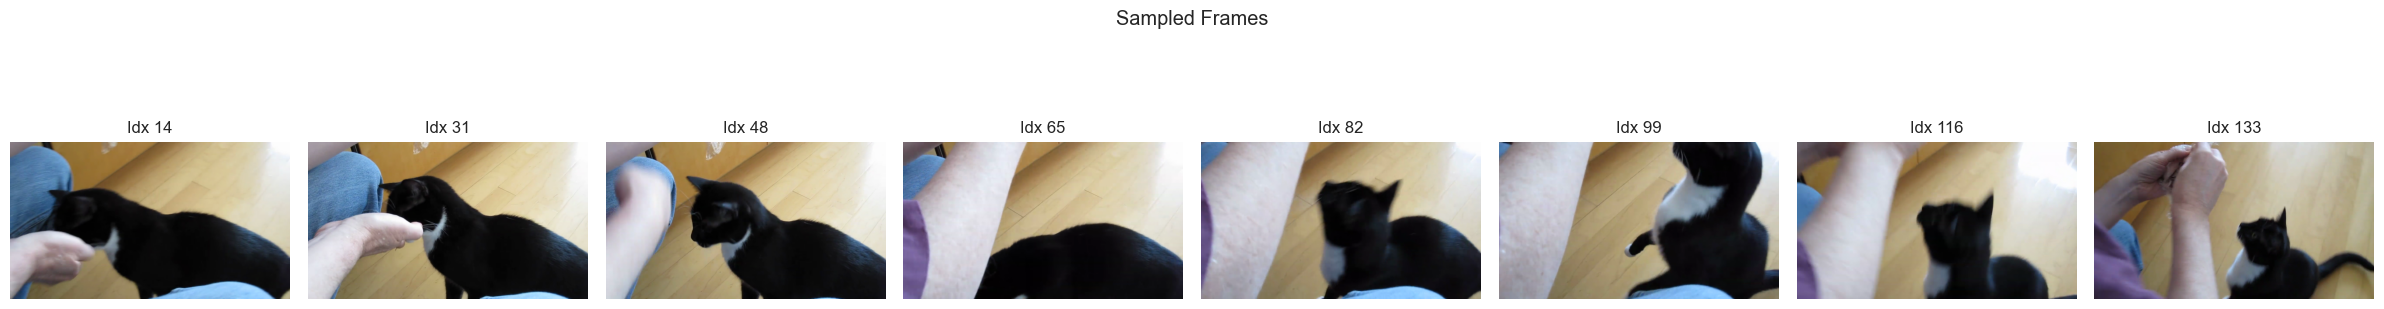

37 37
Successfully processed 37 frames.
Embeddings shape: torch.Size([37, 512])


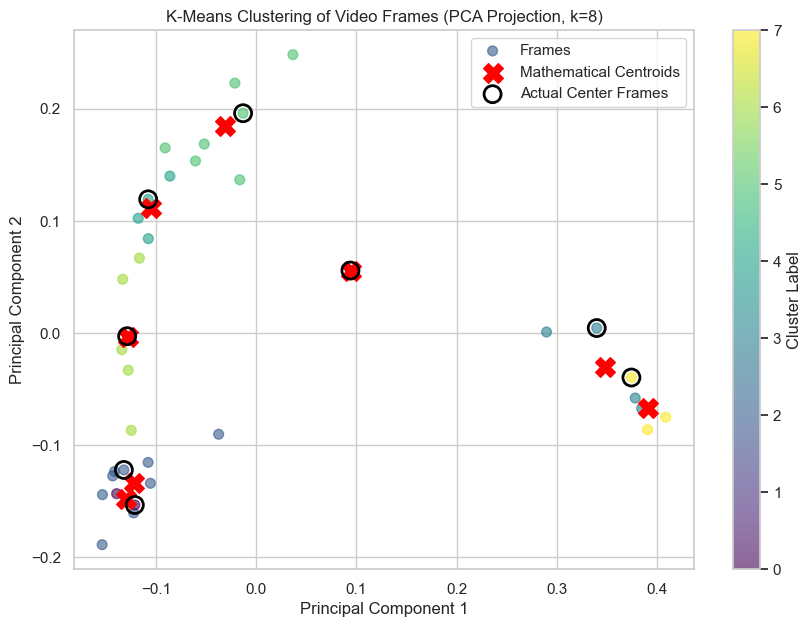

Indices of the most representative frames: [np.int64(13), np.int64(28), np.int64(5), np.int64(31), np.int64(11), np.int64(26), np.int64(18), np.int64(35)]


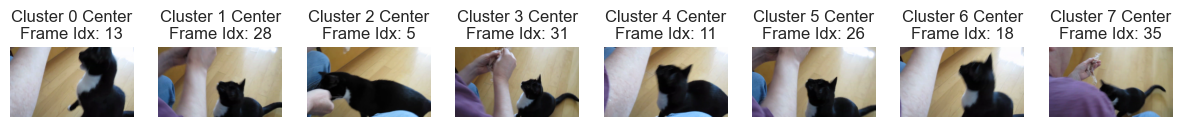

In [178]:
# Assuming you have `embeddings` and `frames` from the previous steps
num_clusters = 8

# 1. Load the frames (assuming you want frames 0, 10, 20, 30)
random_video_path = f"dataset_snippets/{df.filename.sample().values[0]}"
print(f"Random video path: {random_video_path}")

analyze_temporal_sampling_sns(random_video_path, num_frames=8, show_sampled_frames=True)

diffs, total_frames = compute_frame_differences(random_video_path)

top_k_indices = select_top_motion_ratio(diffs, K)

loaded_frames = load_frames_by_indices(random_video_path, top_k_indices)
print(len(loaded_frames), len(top_k_indices))

# 2. Get the embeddings
if loaded_frames:
    embeddings = get_frame_embeddings(loaded_frames, model, preprocess, device, batch_size=16)

    print(f"Successfully processed {len(loaded_frames)} frames.")
    print(f"Embeddings shape: {embeddings.shape}") # Should be (4, 512)
else:
    print("No frames were loaded.")

center_frames, center_indices = cluster_and_get_center_frames(embeddings, loaded_frames, num_clusters=num_clusters)

print(f"Indices of the most representative frames: {center_indices}")

# Optional: Display the center frames using matplotlib
fig, axes = plt.subplots(1, num_clusters, figsize=(15, 5))
for i, ax in enumerate(axes):
    # OpenCV loads images in BGR, but our initial function converted them to RGB!
    # So we can plot them directly with matplotlib.
    ax.imshow(center_frames[i])
    ax.set_title(f"Cluster {i} Center\nFrame Idx: {center_indices[i]}")
    ax.axis('off')
plt.show()